# Fixed Income Multi-Factor Model Backtesting

## Imports

In [1]:
import os
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from openpyxl import load_workbook, Workbook
from openpyxl.utils.cell import coordinate_from_string, column_index_from_string

from barings_quant.connectors.tools import spark_session
from barings_quant.data_access.core import DataQuery

## Configuration

### Paths & Environment

In [2]:
FOLDER_PATH = 'Input Files'
ENV = 'pr'
TRADE_WEIGHTS_FILE = 'Trade File Template HY - 33 Mom 17-50 Value Risk Rotation 18 May 2026.xlsx'
CUTOFF_DATE = pd.to_datetime("2005-12-31")
INDEX_TYPE = 'H0A0'  # 'C0A0' for IG, 'H0A0' for HY
INDEX_SUFFIX = 'HY' if INDEX_TYPE == 'H0A0' else 'IG'

### Date Range

In [3]:
def generate_month_end_dates(start_year, start_month, end_year, end_month):
    """Generate month-end date strings to import ICE files, always using Feb 28."""
    dates = []
    month_days = {1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30, 7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31}
    year, month = start_year, start_month
    while (year, month) <= (end_year, end_month):
        dates.append(f"{year}-{month:02d}-{month_days[month]:02d}")
        month += 1
        if month > 12:
            month = 1
            year += 1
    return dates

DATE_STRINGS = generate_month_end_dates(2005, 6, 2026, 4)

### Mappings & Weights

In [4]:
# Rating mapping: rating → (rank, quintile)
IG_RATING_MAPPING = {
    'AAA': (0.1, 1), 
    'AA1': (0.2, 1),
    'AA2': (0.3, 2),
    'AA3': (0.4, 2),
    'A1': (0.5, 3),
    'A2': (0.6, 3),
    'A3': (0.7, 4),
    'BBB1': (0.8, 4),
    'BBB2': (0.9, 5),
    'BBB3': (1, 5),
}

HY_RATING_MAPPING = {
    'BBB3': (0.083333333, 1),
    'BB1': (0.166666667, 1),
    'BB2': (0.25, 2),
    'BB3': (0.333333333, 2),
    'B1': (0.416666667, 3),
    'B2': (0.5, 3),
    'B3': (0.583333333, 3),
    'CCC1': (0.666666667, 4),
    'CCC2': (0.75, 4),
    'CCC3': (0.833333333, 4),
    'CC': (0.916666667, 5),
    'C': (1, 5),
}

# 4-factor model weights
FOUR_FACTOR_WEIGHTS = {
    'company_index_weight_rank': 0.25,
    'low_risk_paper_rank': 0.25,
    'Value_regression_percentage_deviation_inc_OAS_rank': 0.25,
    '6_month_momentum_rank': 0.25,
}

FOUR_FACTOR_WEIGHTS_ZERO = {
    'company_index_weight_rank': 0,
    'low_risk_paper_rank': 0,
    'Value_regression_percentage_deviation_inc_OAS_rank': 0,
    '6_month_momentum_rank': 0,
}

# Quintile columns for charting / export
QUINTILE_COLUMNS = [
    '4_factor_quintile',
    '4_factor_regime_adjusted_TradeAmount_YP_quintile',
    '4_factor_regime_adjusted_TradeAmount_LE_quintile',
    'company_index_weight_quintile',
    '6_month_momentum_quintile',
    'Value_regression_percentage_deviation_inc_OAS_quintile',
    'low_risk_paper_quintile',
]

QUINTILE_RENAMES = {
    '4_factor_quintile': '4_factor_original',
    '4_factor_regime_adjusted_TradeAmount_YP_quintile': '4_factor_YP',
    '4_factor_regime_adjusted_TradeAmount_LE_quintile': '4_factor_LE',
    'company_index_weight_quintile': 'size',
    '6_month_momentum_quintile': '6_month_momentum',
    'Value_regression_percentage_deviation_inc_OAS_quintile': 'value',
    'low_risk_paper_quintile': 'low_risk',
}

# Trade weight factor name mapping
TRADE_FACTOR_RENAMES = {
    'Value_Rating_Maturity_OAS': 'Value_regression_percentage_deviation_inc_OAS_rank',
    '6_month_momentum': '6_month_momentum_rank',
    'Company_index_weight': 'company_index_weight_rank',
    'low_risk_paper': 'low_risk_paper_rank',
}

# Columns to export in historical screens
EXPORT_COLUMNS = [
    'ISIN number', 'Description', 'Maturity Date', 'effective_rating', 'ISO Currency Code',
    'Industry Lvl 1 Desc', 'Industry Lvl 2 Desc', 'Industry Lvl 3 Desc', 'Industry Lvl 4 Desc',
    'percentile_rank_4_factor',
    'percentile_rank_4_factor_regime_adjusted_TradeAmount_YP',
    'percentile_rank_4_factor_regime_adjusted_TradeAmount_LE',
    'Value_regression_percentage_deviation_inc_OAS_rank',
    '6_month_momentum_rank', 'company_index_weight_rank', 'low_risk_paper_rank',
    'Price', 'oas', 'Yield to Worst', 'Mod. Dur to Worst (s.a.)',
    'Accrued Interest', '% Mkt Value', '% MktVal-PrevMend', 'Cash', 'OAS MTD Change',
    'Asset Swap Spread', 'Asset Swap MTD Chg', 'Effective Yield', 'Yield to Maturity',
    'Total Return % MTD_LOC', 'Excess Return % MTD', 'Effective Duration',
    'Modified Duration (s.a.)', 'Effective Convexity', 'Convexity to Worst (s.a.)',
    'Convexity (s.a.)', 'file_date',
]

## Helper Functions

### Date & Quintile Utilities

In [5]:
def shift_to_month_end(date):
    """Shift date to month-end, always using Feb 28 for February."""
    if date.month == 2:
        return pd.Timestamp(year=date.year, month=2, day=28)
    return date + pd.offsets.MonthEnd(0)


def safe_qcut(series, q=5):
    """Assign quintiles, returning NaN if insufficient data."""
    if series.notnull().sum() < q:
        return pd.Series(np.nan, index=series.index)
    return pd.qcut(series, q, labels=False, duplicates='drop') + 1


def assign_quintiles(group):
    """Assign quintiles to a group, returning NaN on failure."""
    try:
        return pd.qcut(group, 5, labels=False, duplicates='drop') + 1
    except Exception:
        return pd.Series(np.nan, index=group.index)


def assign_quintiles_higher_better(x):
    """Quintiles where higher values = quintile 1 (best)."""
    non_na = x.dropna()
    if non_na.empty:
        return pd.Series(np.nan, index=x.index)
    try:
        quintiles = pd.qcut(-non_na, 5, labels=False, duplicates='drop') + 1
    except ValueError:
        return pd.Series(np.nan, index=x.index)
    return pd.Series(quintiles, index=non_na.index).reindex(x.index)


def assign_quintiles_lower_better(x):
    """Quintiles where lower values = quintile 1 (best)."""
    non_na = x.dropna()
    if non_na.empty:
        return pd.Series(np.nan, index=x.index)
    try:
        quintiles = pd.qcut(non_na, 5, labels=False, duplicates='drop') + 1
    except ValueError:
        return pd.Series(np.nan, index=x.index)
    return pd.Series(quintiles, index=non_na.index).reindex(x.index)

### Return & Turnover Metrics

In [6]:
def annualized_return(returns, periods_per_year=12):
    compounded_growth = (1 + returns).prod()
    n_periods = returns.shape[0]
    return compounded_growth ** (periods_per_year / n_periods) - 1


def annualized_volatility(returns, periods_per_year=12):
    return returns.std() * np.sqrt(periods_per_year)


def calculate_turnover(df, quintile_col):
    df = df.sort_values(by=['Cusip', 'file_date']).copy()
    df['shifted_quintile'] = df.groupby('Cusip')[quintile_col].shift(1)
    return df[df[quintile_col] != df['shifted_quintile']].shape[0] / df.shape[0]


def monthly_turnover(df, quintile_col):
    df = df.sort_values(by=['Cusip', 'file_date']).copy()
    df['shifted_quintile'] = df.groupby('Cusip')[quintile_col].shift(1)
    df['changed'] = df[quintile_col] != df['shifted_quintile']
    monthly = df.groupby(df['file_date'].dt.to_period('M'))['changed'].mean()
    monthly.index = monthly.index.to_timestamp()
    return monthly.rolling(window=12).mean()

### DataFrame Utilities

In [7]:
def fill_na_with_group_median(df, columns, group_col='file_date'):
    """Fill NaN values with per-group median."""
    for col in columns:
        df[col] = df.groupby(group_col)[col].transform(lambda x: x.fillna(x.median()))
    return df


def fill_na_with_group_then_global_median(df, columns, group_col='file_date'):
    """Fill NaN with per-group median, then global median as fallback."""
    for col in columns:
        df[col] = df[col].fillna(df.groupby(group_col)[col].transform('median'))
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())
    return df


def clean_and_convert_to_numeric(df, columns):
    """Strip non-numeric characters and convert columns to numeric."""
    for col in columns:
        df[col] = df[col].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def clean_sheet_name(name):
    """Remove invalid Excel sheet name characters and truncate to 31 chars."""
    for char in ['\\', '/', '*', '?', ':', '[', ']']:
        name = name.replace(char, '')
    return name[:31]


def attach_next_month_returns(df):
    """Merge next-month excess returns onto each row by Cusip and period."""
    df = df.copy()
    df['file_date'] = pd.to_datetime(df['file_date'])
    df['year_month'] = df['file_date'].dt.to_period('M')
    df['next_year_month'] = df['year_month'] + 1

    next_month = df[['Cusip', 'year_month', 'Excess Return % MTD']].rename(columns={
        'year_month': 'prev_year_month',
        'Excess Return % MTD': 'next_month_return',
    })
    return df.merge(
        next_month,
        left_on=['Cusip', 'next_year_month'],
        right_on=['Cusip', 'prev_year_month'],
        how='left',
    )

### ICE Data Processor

In [8]:
class ICEDataProcessor:
    SHEET_NAME_MAPPINGS = {
        'C0A0': {
            '01-31': 'C0A03101 ', '02-28': 'C0A02802 ', '03-31': 'C0A03103 ',
            '04-30': 'C0A03004 ', '05-31': 'C0A03105 ', '06-30': 'C0A03006 ',
            '07-31': 'C0A03107 ', '08-31': 'C0A03108 ', '09-30': 'C0A03009 ',
            '10-31': 'C0A03110 ', '11-30': 'C0A03011 ', '12-31': 'C0A03112 ',
        },
        'H0A0': {
            '01-31': 'H0A00131 ', '02-28': 'H0A00228 ', '03-31': 'H0A00331 ',
            '04-30': 'H0A00430 ', '05-31': 'H0A00531 ', '06-30': 'H0A00630 ',
            '07-31': 'H0A00731 ', '08-31': 'H0A00831 ', '09-30': 'H0A00930 ',
            '10-31': 'H0A01031 ', '11-30': 'H0A01130 ', '12-31': 'H0A01231 ',
        },
    }
    COLUMN_MAPPING = {
        'OAS': 'oas',
        'Yield to Maturity (s.a.)': 'Yield to Maturity',
        'Yield to Worst (s.a.)': 'Yield to Worst',
        'Rating': 'effective_rating',
    }

    def __init__(self, folder_path, index_type='C0A0'):
        self.folder_path = folder_path
        self.index_type = index_type

    def get_sheet_name(self, date_obj):
        return self.SHEET_NAME_MAPPINGS[self.index_type].get(date_obj.strftime('%m-%d'))

    def process_file(self, date_str):
        date_obj = datetime.strptime(date_str, '%Y-%m-%d')
        date_format = '%d%m%Y' if self.index_type == 'C0A0' else '%m%d%Y'
        file_name = f"{self.index_type}-{date_obj.strftime(date_format)}.xlsx"
        sheet_name = self.get_sheet_name(date_obj)
        file_path = os.path.join(self.folder_path, file_name)

        if not sheet_name:
            print(f"\u26a0\ufe0f No sheet name found for {date_str}")
            return None
        try:
            df = pd.read_excel(file_path, sheet_name=sheet_name)
            df = df.rename(columns=self.COLUMN_MAPPING)
            df['file_date'] = date_str
            print(f"\u2705 Processed {file_name} - {sheet_name}")
            return df
        except Exception as e:
            print(f"\u274c Failed to process {file_name} - {sheet_name}: {e}")
            return None

    def process_all_dates(self, date_strings):
        frames = [self.process_file(d) for d in date_strings]
        return pd.concat([f for f in frames if f is not None], ignore_index=True)

### Excel Export Utilities

In [9]:
def a1_to_rowcol_1based(a1_cell: str):
    """Convert Excel A1 cell (e.g., 'B2') -> (row, col) in 1-based indexing."""
    col_letters, row = coordinate_from_string(a1_cell)
    col = column_index_from_string(col_letters)
    return row, col


def ensure_workbook(path: str):
    """Load workbook if exists; otherwise create a new one."""
    if os.path.exists(path):
        return load_workbook(path)
    wb = Workbook()
    if wb.active and wb.active.title == "Sheet":
        wb.remove(wb.active)
    return wb


def ensure_sheet(wb, sheet_name: str):
    """Get or create worksheet."""
    if sheet_name in wb.sheetnames:
        return wb[sheet_name]
    return wb.create_sheet(sheet_name)


def clear_block(ws, start_cell: str, nrows: int, ncols: int):
    """Clear a rectangular block starting at start_cell."""
    r0, c0 = a1_to_rowcol_1based(start_cell)
    for r in range(r0, r0 + nrows):
        for c in range(c0, c0 + ncols):
            ws.cell(row=r, column=c).value = None


def write_df_to_ws(ws, df: pd.DataFrame, start_cell: str = "A1", include_header: bool = True):
    """Write DataFrame values to a sheet starting at start_cell."""
    r0, c0 = a1_to_rowcol_1based(start_cell)
    row_offset = 0
    if include_header:
        for j, col in enumerate(df.columns):
            ws.cell(row=r0, column=c0 + j).value = col
        row_offset = 1
    for i, row in enumerate(df.itertuples(index=False), start=0):
        for j, val in enumerate(row):
            ws.cell(row=r0 + row_offset + i, column=c0 + j).value = val


def upsert_table(
    wb, sheet_name: str, df: pd.DataFrame, start_cell: str = "A1",
    clear: bool = True, clear_padding: tuple = (2000, 50), reset_index: bool = True,
):
    """Ensure sheet exists, clear a reserved block, and write df."""
    ws = ensure_sheet(wb, sheet_name)
    out_df = df.reset_index() if reset_index else df.copy()
    if clear:
        clear_rows, clear_cols = clear_padding
        clear_block(ws, start_cell, clear_rows, clear_cols)
    write_df_to_ws(ws, out_df, start_cell=start_cell, include_header=True)

---
## 1. Load ICE Index Data

In [10]:
processor = ICEDataProcessor(FOLDER_PATH, INDEX_TYPE)
ice_combined_df = processor.process_all_dates(DATE_STRINGS)

ice_combined_df['Excess Return % MTD'] = ice_combined_df['Excess Return % MTD'] / 100

portfolio_level_holdings_main = ice_combined_df

✅ Processed H0A0-06302005.xlsx - H0A00630 
✅ Processed H0A0-07312005.xlsx - H0A00731 
✅ Processed H0A0-08312005.xlsx - H0A00831 
✅ Processed H0A0-09302005.xlsx - H0A00930 
✅ Processed H0A0-10312005.xlsx - H0A01031 
✅ Processed H0A0-11302005.xlsx - H0A01130 
✅ Processed H0A0-12312005.xlsx - H0A01231 
✅ Processed H0A0-01312006.xlsx - H0A00131 
✅ Processed H0A0-02282006.xlsx - H0A00228 
✅ Processed H0A0-03312006.xlsx - H0A00331 
✅ Processed H0A0-04302006.xlsx - H0A00430 
✅ Processed H0A0-05312006.xlsx - H0A00531 
✅ Processed H0A0-06302006.xlsx - H0A00630 
✅ Processed H0A0-07312006.xlsx - H0A00731 
✅ Processed H0A0-08312006.xlsx - H0A00831 
✅ Processed H0A0-09302006.xlsx - H0A00930 
✅ Processed H0A0-10312006.xlsx - H0A01031 
✅ Processed H0A0-11302006.xlsx - H0A01130 
✅ Processed H0A0-12312006.xlsx - H0A01231 
✅ Processed H0A0-01312007.xlsx - H0A00131 
✅ Processed H0A0-02282007.xlsx - H0A00228 
✅ Processed H0A0-03312007.xlsx - H0A00331 
✅ Processed H0A0-04302007.xlsx - H0A00430 
✅ Processed

## 2. Value Factor

Regression Function

In [19]:
def run_cross_sectional_regression(df, date, regression_columns, return_model=False):
    """Run OLS cross-sectional regression for a single date."""
    df_date = df[df['file_date'] == date]
    rating_dummies = pd.get_dummies(df_date['effective_rating'])

    X = pd.concat([rating_dummies, df_date[regression_columns]], axis=1).astype(float)
    X = sm.add_constant(X)
    y = df_date['oas_value'].astype(float)

    mask = X.notnull().all(axis=1) & ~np.isinf(X).any(axis=1) & y.notnull() & ~np.isinf(y)
    X_clean, y_clean = X[mask], y[mask]

    if len(X_clean) == 0:
        return None

    model = sm.OLS(y_clean, X_clean).fit()
    fitted = model.fittedvalues
    pct_deviation = ((y[mask] - fitted) / fitted) * 100
    out = pd.DataFrame({
        'fitted_spread_inc_OAS': fitted,
        'Value_regression_percentage_deviation_inc_OAS': pct_deviation,
    }, index=df_date.index[mask])

    return (out, model) if return_model else out


Calculate OAS change, time to maturity, and run the value regression.

In [20]:
portfolio_level_holdings = portfolio_level_holdings_main.copy()
portfolio_level_holdings = portfolio_level_holdings.rename(columns={'Ticker': 'ticker'})
portfolio_level_holdings['file_date'] = pd.to_datetime(portfolio_level_holdings['file_date'])

# Copy yield / OAS columns for later use
portfolio_level_holdings['Yield to Maturity_value'] = portfolio_level_holdings['Yield to Maturity']
portfolio_level_holdings['Yield to Worst_value'] = portfolio_level_holdings['Yield to Worst']
portfolio_level_holdings['oas_value'] = portfolio_level_holdings['oas']

# 3-month OAS change
portfolio_level_holdings = portfolio_level_holdings.sort_values(by=['ISIN number', 'file_date'])
portfolio_level_holdings['oas_value_3_month_change'] = (portfolio_level_holdings.groupby('ISIN number')['oas_value'].diff(periods=3))

# Time to maturity (years)
portfolio_level_holdings['Maturity Date'] = pd.to_datetime(portfolio_level_holdings['Maturity Date'])
portfolio_level_holdings['Maturity'] = ((portfolio_level_holdings['Maturity Date'] - portfolio_level_holdings['file_date']).dt.days / 365.25)

# Cross-sectional regression for each date
# Given a bond’s rating, maturity, and its 3‑month OAS change, what OAS should it typically trade at relative to its peers
results = pd.DataFrame()
for date in portfolio_level_holdings['file_date'].unique():
    reg = run_cross_sectional_regression(
        portfolio_level_holdings, date,
        regression_columns=['Maturity', 'oas_value_3_month_change'],
    )
    if reg is not None:
        results = pd.concat([results, reg])


print(f"Regression deviation sum: {results['Value_regression_percentage_deviation_inc_OAS'].sum():.2f}")
print(f"Fitted spread sum: {results['fitted_spread_inc_OAS'].sum():.2f}")

# The deviation tells us - Is this bond wide/cheap or tight/rich relative to similar bonds
portfolio_level_holdings['Value_regression_percentage_deviation_inc_OAS'] = results['Value_regression_percentage_deviation_inc_OAS']

# Fitted/predicted OAS from regression (i.e. OAS explained by rating, maturity, and 3-month OAS change)  
portfolio_level_holdings['fitted_spread_inc_OAS'] = results['fitted_spread_inc_OAS']

Regression deviation sum: 1674954.03
Fitted spread sum: 279653918.00


Rows in plot cross-section: 1796


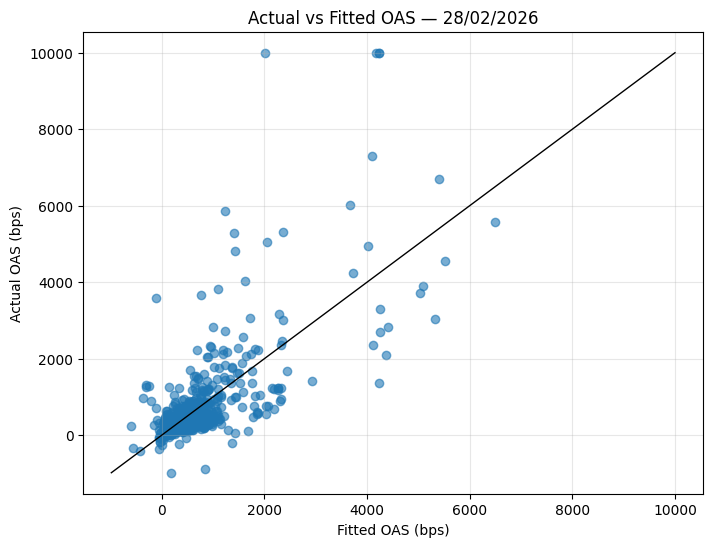

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plot_date = pd.Timestamp("2026-02-28")

df_plot = portfolio_level_holdings.loc[
    portfolio_level_holdings["file_date"].eq(plot_date),
    [
        "file_date",
        "ISIN number",
        "ticker",
        "effective_rating",
        "oas_value",
        "fitted_spread_inc_OAS",
        "Value_regression_percentage_deviation_inc_OAS",
        "Maturity",
        "oas_value_3_month_change",
    ]
].copy()

# Keep only rows where regression produced outputs
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)
df_plot = df_plot.dropna(subset=["oas_value", "fitted_spread_inc_OAS", "Value_regression_percentage_deviation_inc_OAS"])

print("Rows in plot cross-section:", len(df_plot))
df_plot.head()


plt.figure(figsize=(8, 6))
plt.scatter(df_plot["fitted_spread_inc_OAS"], df_plot["oas_value"], alpha=0.6)

# 45-degree line
mn = min(df_plot["fitted_spread_inc_OAS"].min(), df_plot["oas_value"].min())
mx = max(df_plot["fitted_spread_inc_OAS"].max(), df_plot["oas_value"].max())
plt.plot([mn, mx], [mn, mx], color="black", linewidth=1)

plt.title(f"Actual vs Fitted OAS — {plot_date:%d/%m/%Y}")
plt.xlabel("Fitted OAS (bps)")
plt.ylabel("Actual OAS (bps)")
plt.grid(True, alpha=0.3)
plt.show()

In [21]:

plot_date = pd.Timestamp("2026-02-28")

out_0228, model_0228 = run_cross_sectional_regression(
    portfolio_level_holdings,
    plot_date,
    regression_columns=["Maturity", "oas_value_3_month_change"],
    return_model=True
)

print(model_0228.summary())


                            OLS Regression Results                            
Dep. Variable:              oas_value   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     186.9
Date:                Sun, 24 May 2026   Prob (F-statistic):          1.15e-304
Time:                        18:32:17   Log-Likelihood:                -13722.
No. Observations:                1796   AIC:                         2.747e+04
Df Residuals:                    1783   BIC:                         2.754e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

## 3. Momentum & Volatility Factors
6-month and 3-month cumulative excess return (1-month lag) and 12-month annualised std dev.

In [13]:
portfolio_level_holdings = portfolio_level_holdings.sort_values(by=['ISIN number', 'file_date'])

for col_name, window in [('6_month_momentum', 6), ('3_month_momentum', 3)]:
    portfolio_level_holdings[col_name] = (
        portfolio_level_holdings.groupby('ISIN number')['Excess Return % MTD']
        .transform(lambda x: (1 + x.shift(1)).rolling(window=window).apply(np.prod, raw=True) - 1)
    )

portfolio_level_holdings['annualised_std_dev'] = (
    portfolio_level_holdings.groupby('ISIN number')['Excess Return % MTD']
    .transform(lambda x: x.rolling(window=12).std() * np.sqrt(12))
)

display(portfolio_level_holdings.head())

,Cusip,ISIN number,Description,ticker,Par Wtd Coupon,Maturity Date,effective_rating,ISO Currency Code,ISO Country Code,Industry Lvl 1 Desc,...,Yield to Maturity_value,Yield to Worst_value,oas_value,oas_value_3_month_change,Maturity,Value_regression_percentage_deviation_inc_OAS,fitted_spread_inc_OAS,6_month_momentum,3_month_momentum,annualised_std_dev
186204,EJ706633,BE6254004268,Barry Callebaut Services Nv,BARY,5.5,2023-06-15,BB1,USD,BE,Corporate,...,5.41,5.41,300,NaN,9.957563,NaN,NaN,NaN,NaN,NaN
188349,EJ706633,BE6254004268,Barry Callebaut Services Nv,BARY,5.5,2023-06-15,BB1,USD,BE,Corporate,...,5.11,5.11,259,NaN,9.872690,NaN,NaN,NaN,NaN,NaN
190508,EJ706633,BE6254004268,Barry Callebaut Services Nv,BARY,5.5,2023-06-15,BB1,USD,BE,Corporate,...,5.42,5.42,276,NaN,9.787817,NaN,NaN,NaN,NaN,NaN
192704,EJ706633,BE6254004268,Barry Callebaut Services Nv,BARY,5.5,2023-06-15,BB1,USD,BE,Corporate,...,5.44,5.44,295,-5.0,9.705681,-5.678202,312.759095,NaN,NaN,NaN
194913,EJ706633,BE6254004268,Barry Callebaut Services Nv,BARY,5.5,2023-06-15,BB1,USD,BE,Corporate,...,5.32,5.32,291,32.0,9.620808,-6.655642,311.748890,NaN,0.011314,NaN


## 4. Fill Missing Data with Group Median

In [14]:
portfolio_level_holdings = fill_na_with_group_median(portfolio_level_holdings, [
    'annualised_std_dev',
    'Value_regression_percentage_deviation_inc_OAS',
])

c:\Users\feme\OneDrive - Barings\feme\python_source_code\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\feme\OneDrive - Barings\feme\python_source_code\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\feme\OneDrive - Barings\feme\python_source_code\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\feme\OneDrive - Barings\feme\python_source_code\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\feme\OneDrive - Barings\feme\python_source_code\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis

## 5. Size Factor
Total index weight of each company (issuer-level aggregation).

In [15]:
portfolio_level_holdings['Ticker'] = portfolio_level_holdings['ticker'].astype(str)
portfolio_level_holdings['% Mkt Value'] = pd.to_numeric(portfolio_level_holdings['% Mkt Value'], errors='coerce')

portfolio_level_holdings['company_index_weight'] = (
    portfolio_level_holdings.groupby(['file_date', 'Ticker'], dropna=False)['% Mkt Value']
    .transform('sum')
)

## 6. Fixed Income Factor Ranks & Quintiles

In [16]:
fi_columns_to_clean = [
    'oas_value', 'Yield to Maturity_value', 'Yield to Worst_value',
    '6_month_momentum', '3_month_momentum',
    'company_index_weight', 'Value_regression_percentage_deviation_inc_OAS',
]
clean_and_convert_to_numeric(portfolio_level_holdings, fi_columns_to_clean)

for col in ['oas_value', 'Yield to Maturity_value', 'Yield to Worst_value', 'company_index_weight']:
    if portfolio_level_holdings[col].isnull().any():
        print(f"\u26a0\ufe0f NaN in '{col}' \u2014 filling with median.")
        portfolio_level_holdings[col] = portfolio_level_holdings[col].fillna(
            portfolio_level_holdings[col].median()
        )

# Factor columns: (source_col, prefix, direction)
fi_factor_columns = [
    ('Maturity', 'Maturity', 'lower_better'),
    ('oas_value', 'oas', 'higher_better'),
    ('Yield to Maturity_value', 'Yield to Maturity', 'higher_better'),
    ('Yield to Worst_value', 'Yield to Worst', 'higher_better'),
    ('company_index_weight', 'company_index_weight', 'lower_better'),
    ('6_month_momentum', '6_month_momentum', 'higher_better'),
    ('3_month_momentum', '3_month_momentum', 'higher_better'),
    ('Value_regression_percentage_deviation_inc_OAS', 'Value_regression_percentage_deviation_inc_OAS', 'higher_better'),
]

for col, prefix, direction in fi_factor_columns:
    if direction == 'lower_better':
        portfolio_level_holdings[f'{prefix}_quintile'] = (
            portfolio_level_holdings.groupby('file_date')[col].transform(assign_quintiles_lower_better)
        )
        portfolio_level_holdings[f'{prefix}_rank'] = (
            portfolio_level_holdings.groupby('file_date')[col].rank(pct=True, ascending=True)
        )
    else:
        portfolio_level_holdings[f'{prefix}_quintile'] = (
            portfolio_level_holdings.groupby('file_date')[col].transform(assign_quintiles_higher_better)
        )
        portfolio_level_holdings[f'{prefix}_rank'] = (
            portfolio_level_holdings.groupby('file_date')[col].rank(pct=True, ascending=False)
        )

print("\u2705 FI factor ranks and quintiles assigned.")
display(portfolio_level_holdings.head())

⚠️ NaN in 'company_index_weight' — filling with median.
✅ FI factor ranks and quintiles assigned.


,Cusip,ISIN number,Description,ticker,Par Wtd Coupon,Maturity Date,effective_rating,ISO Currency Code,ISO Country Code,Industry Lvl 1 Desc,...,Yield to Worst_quintile,Yield to Worst_rank,company_index_weight_quintile,company_index_weight_rank,6_month_momentum_quintile,6_month_momentum_rank,3_month_momentum_quintile,3_month_momentum_rank,Value_regression_percentage_deviation_inc_OAS_quintile,Value_regression_percentage_deviation_inc_OAS_rank
186204,EJ706633,BE6254004268,Barry Callebaut Services Nv,BARY,5.5,2023-06-15,BB1,USD,BE,Corporate,...,4,0.706953,2,0.204386,NaN,NaN,NaN,NaN,3.0,0.500233
188349,EJ706633,BE6254004268,Barry Callebaut Services Nv,BARY,5.5,2023-06-15,BB1,USD,BE,Corporate,...,4,0.660019,2,0.204545,NaN,NaN,NaN,NaN,3.0,0.500232
190508,EJ706633,BE6254004268,Barry Callebaut Services Nv,BARY,5.5,2023-06-15,BB1,USD,BE,Corporate,...,4,0.656863,1,0.200182,NaN,NaN,NaN,NaN,3.0,0.500228
192704,EJ706633,BE6254004268,Barry Callebaut Services Nv,BARY,5.5,2023-06-15,BB1,USD,BE,Corporate,...,4,0.630435,1,0.198370,NaN,NaN,NaN,NaN,3.0,0.415761
194913,EJ706633,BE6254004268,Barry Callebaut Services Nv,BARY,5.5,2023-06-15,BB1,USD,BE,Corporate,...,3,0.539937,2,0.201264,NaN,NaN,4.0,0.681443,3.0,0.431859


## 7. Rating Mapping

In [17]:
rating_mapping = HY_RATING_MAPPING if INDEX_TYPE == 'H0A0' else IG_RATING_MAPPING
mapping_df = pd.DataFrame.from_dict(rating_mapping, orient='index', columns=['Rating_rank', 'Rating_quintile'])
mapping_df.index.name = 'effective_rating'
mapping_df = mapping_df.reset_index()

portfolio_level_holdings = portfolio_level_holdings.merge(mapping_df, on='effective_rating', how='left')

## 8. Low Risk Factor
Weighted average of maturity rank and rating rank.

In [18]:
low_risk_weights = {'Maturity_rank': 0.5, 'Rating_rank': 0.5}

portfolio_level_holdings = fill_na_with_group_median(
    portfolio_level_holdings, list(low_risk_weights.keys())
)

portfolio_level_holdings['low_risk_paper_rank'] = sum(
    portfolio_level_holdings[col] * w for col, w in low_risk_weights.items()
)
portfolio_level_holdings['low_risk_paper_quintile'] = (
    portfolio_level_holdings.groupby('file_date')['low_risk_paper_rank']
    .transform(assign_quintiles)
)

## 9. Regime Trade Weights & 4-Factor Construction

In [19]:
# Load trade weights
df_trade_weights = pd.read_excel(TRADE_WEIGHTS_FILE, sheet_name="Trading Model Results")
df_trade_weights['Factor'] = df_trade_weights['Factor'].replace(TRADE_FACTOR_RENAMES)

df_trade_weights_pivoted = df_trade_weights.pivot_table(
    index='TradeDate', columns='Factor',
    values=['TradeAmount_YP', 'TradeAmount_LE'], aggfunc='first',
)
df_trade_weights_pivoted.columns = ['_'.join(col).strip() for col in df_trade_weights_pivoted.columns]
df_trade_weights_pivoted = df_trade_weights_pivoted.reset_index()
df_trade_weights_pivoted['TradeDate'] = df_trade_weights_pivoted['TradeDate'].apply(shift_to_month_end)

# Merge trade weights with holdings
portfolio_level_holdings = portfolio_level_holdings.merge(
    df_trade_weights_pivoted, left_on='file_date', right_on='TradeDate', how='left'
)

# Fill missing ranks with group median, then global median
portfolio_level_holdings = fill_na_with_group_then_global_median(
    portfolio_level_holdings, list(FOUR_FACTOR_WEIGHTS.keys())
)

# Compute regime-adjusted weighted ranks
for col, base_weight in FOUR_FACTOR_WEIGHTS_ZERO.items():
    portfolio_level_holdings[f'{col}_TradeAmount_YP_weight_adj'] = (
        (base_weight + portfolio_level_holdings[f'TradeAmount_YP_{col}']) * portfolio_level_holdings[col]
    )
    portfolio_level_holdings[f'{col}_TradeAmount_LE_weight_adj'] = (
        (base_weight + portfolio_level_holdings[f'TradeAmount_LE_{col}']) * portfolio_level_holdings[col]
    )

# 4-factor composite ranks
portfolio_level_holdings['4_factor_rank'] = sum(
    portfolio_level_holdings[col] * w for col, w in FOUR_FACTOR_WEIGHTS.items()
)
portfolio_level_holdings['4_factor_regime_adjusted_TradeAmount_YP_rank'] = sum(
    portfolio_level_holdings[f'{col}_TradeAmount_YP_weight_adj'] for col in FOUR_FACTOR_WEIGHTS_ZERO
)
portfolio_level_holdings['4_factor_regime_adjusted_TradeAmount_LE_rank'] = sum(
    portfolio_level_holdings[f'{col}_TradeAmount_LE_weight_adj'] for col in FOUR_FACTOR_WEIGHTS_ZERO
)

# Assign quintiles
for rank_col in ['4_factor_rank',
                 '4_factor_regime_adjusted_TradeAmount_YP_rank',
                 '4_factor_regime_adjusted_TradeAmount_LE_rank']:
    quintile_col = rank_col.replace('_rank', '_quintile')
    portfolio_level_holdings[quintile_col] = (
        portfolio_level_holdings.groupby('file_date')[rank_col]
        .transform(assign_quintiles)
    )

## 10. Active Sector Weights by Quintile

Compare the equal-weighted portfolio sector allocation against the benchmark (cap-weighted) sector allocation per quintile:
- **Benchmark**: sector weight = sum of `% Mkt Value` for stocks in that sector within each quintile
- **Portfolio**: each quintile = 20%; each stock in a quintile gets `20% / n_stocks_in_quintile`; sector weight = bond weight × count of sector bonds in that quintile
- **Active** = portfolio sector weight − benchmark sector weight

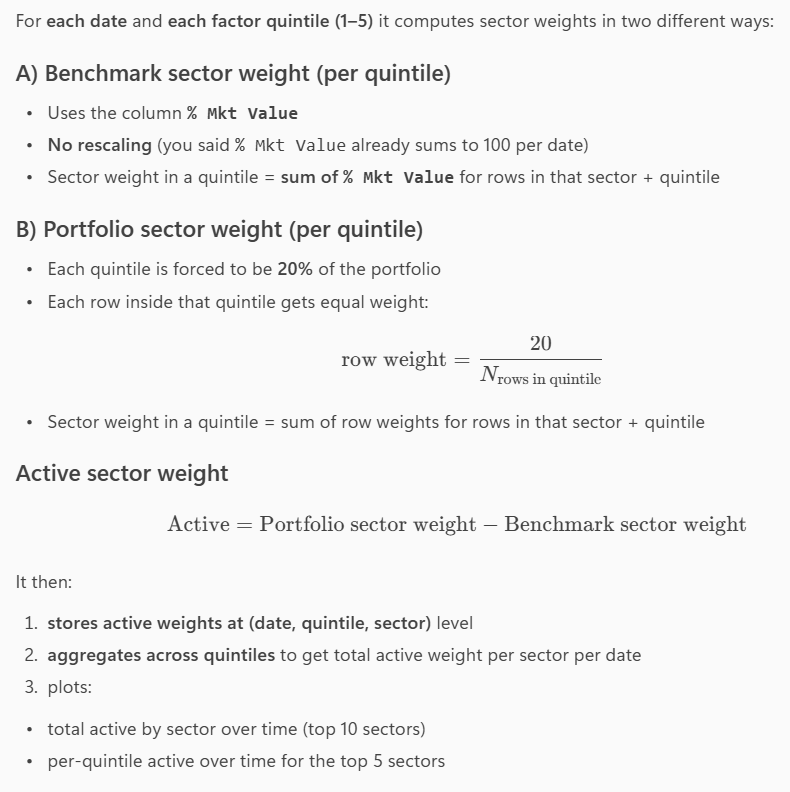

Benchmark total (should be ~100 each date):
count    250.000000
mean     100.000002
std        0.000013
min       99.999959
25%       99.999994
50%      100.000002
75%      100.000011
max      100.000040
Name: benchmark_total, dtype: float64

Portfolio total (should be ~100 IF all 5 quintiles exist each date):
count    2.500000e+02
mean     1.000000e+02
std      2.205952e-15
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
Name: portfolio_total, dtype: float64


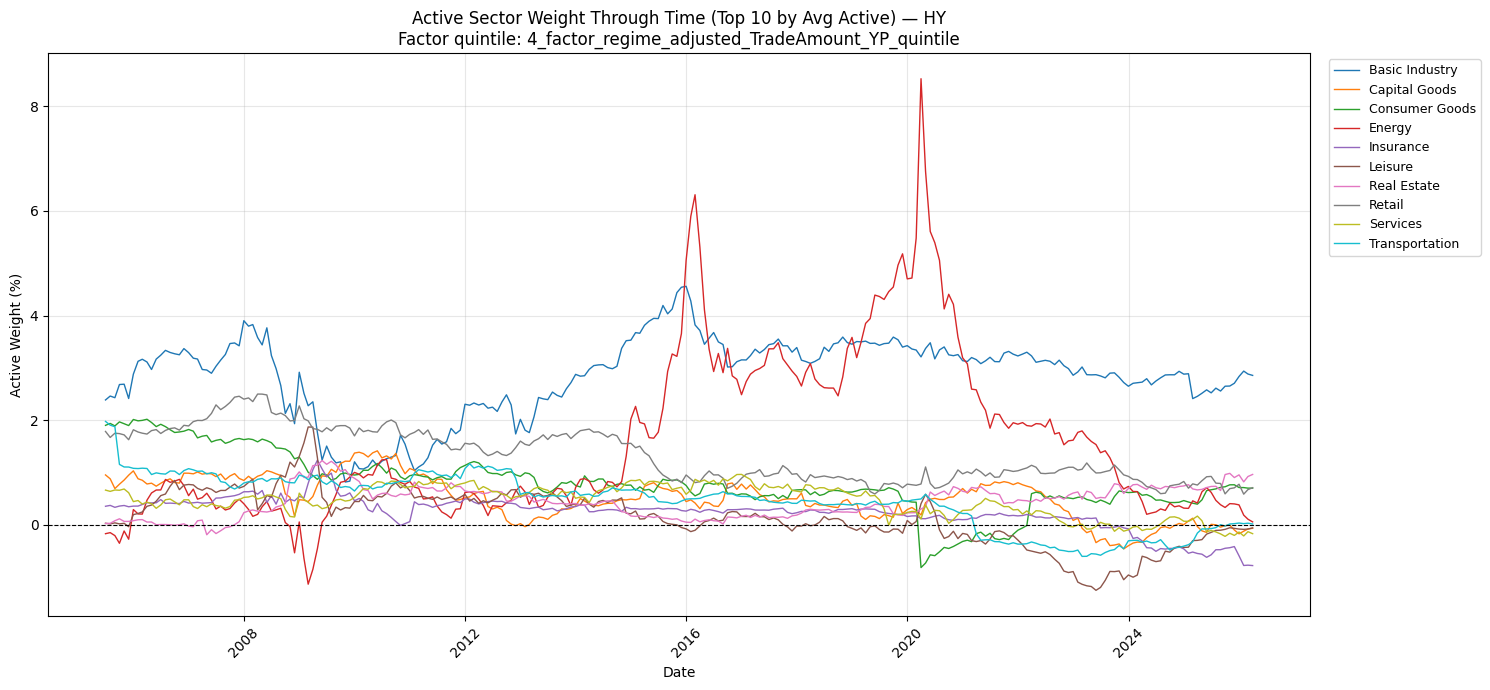

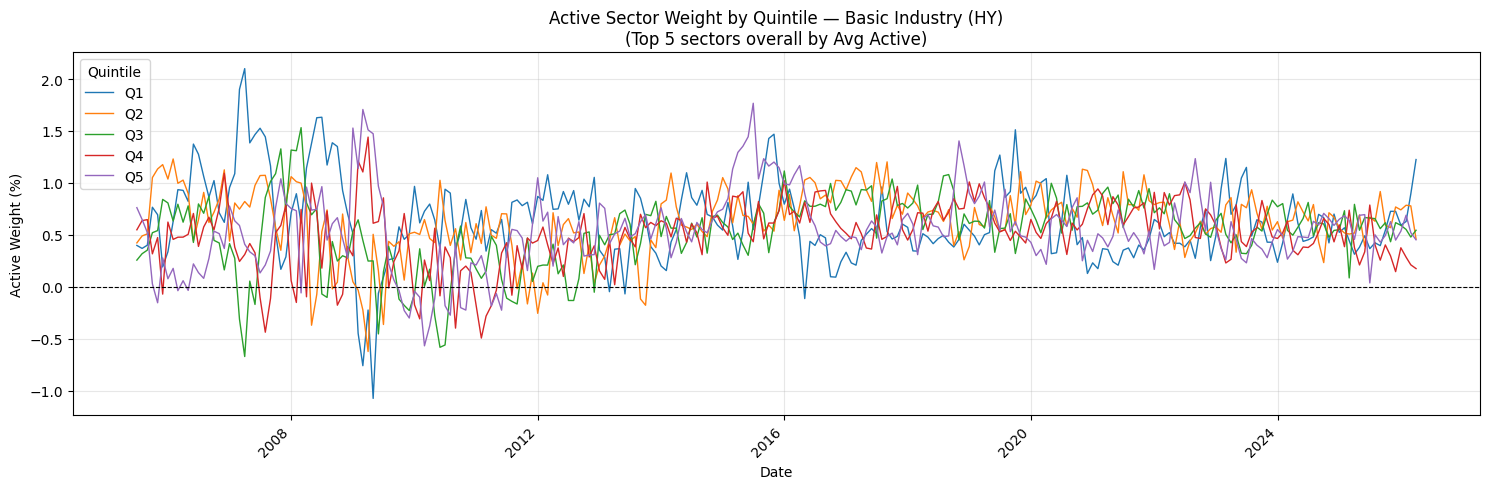

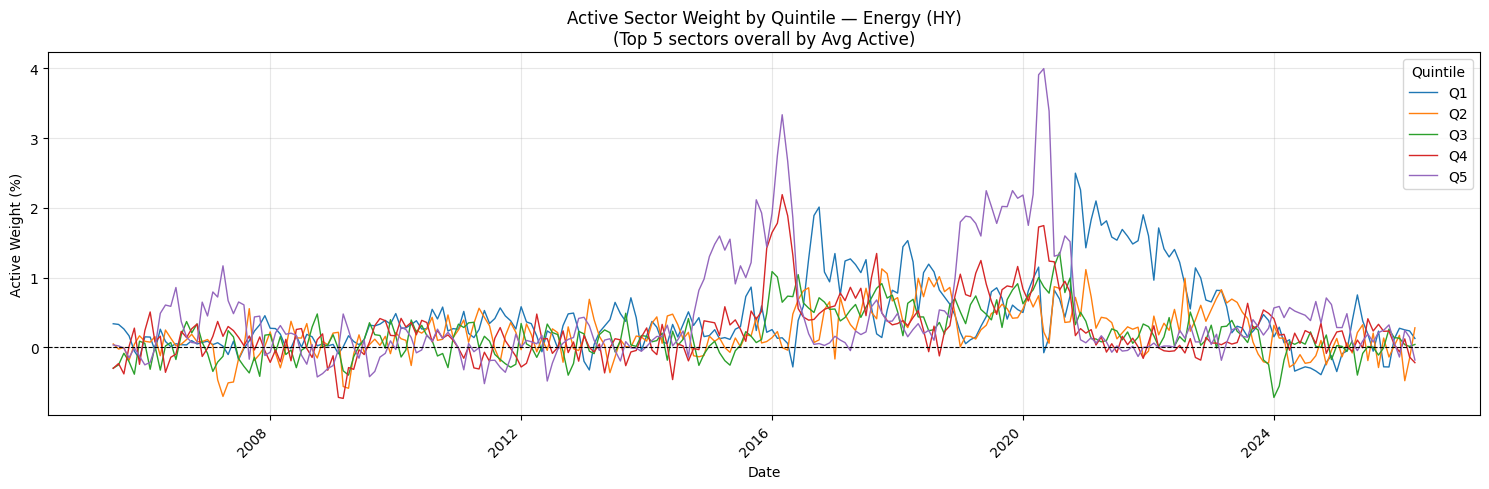

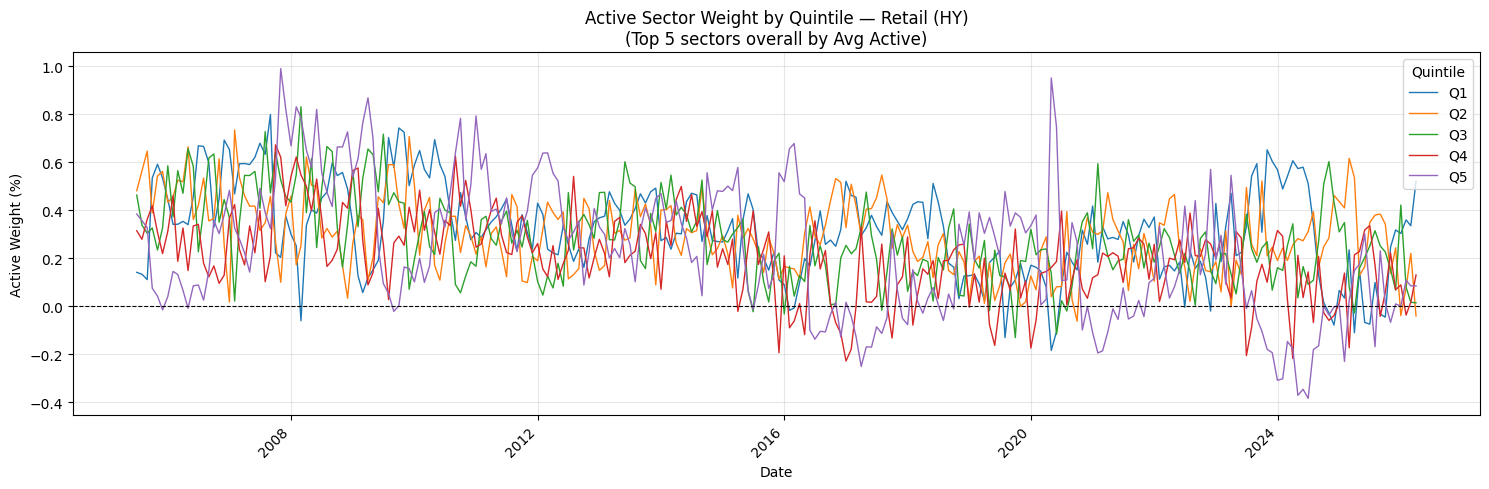

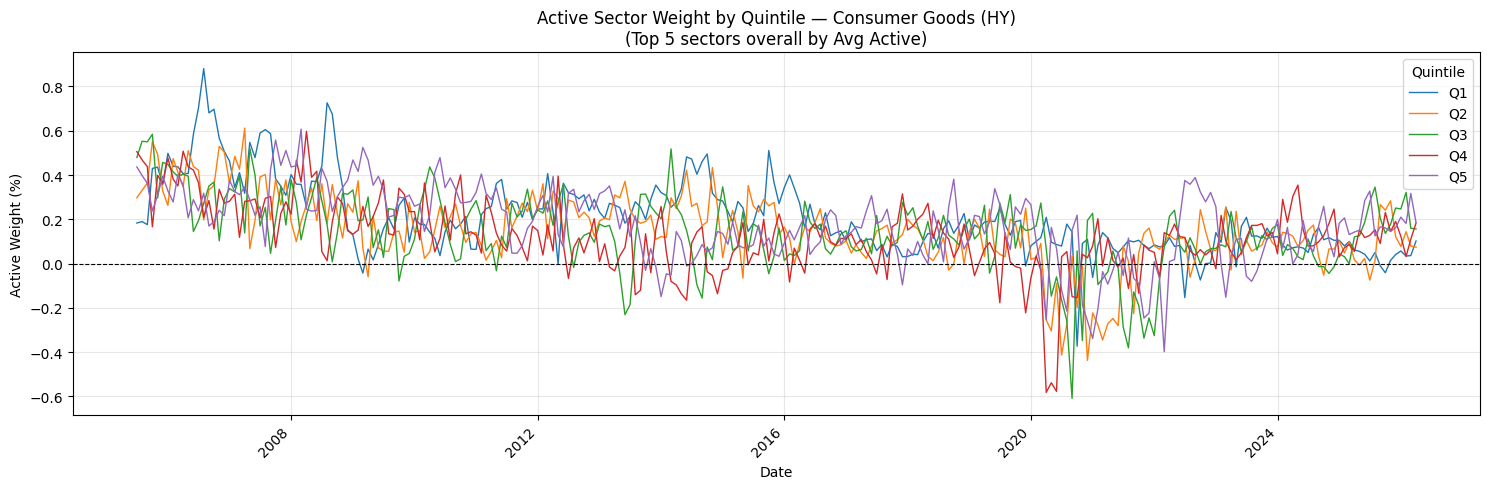

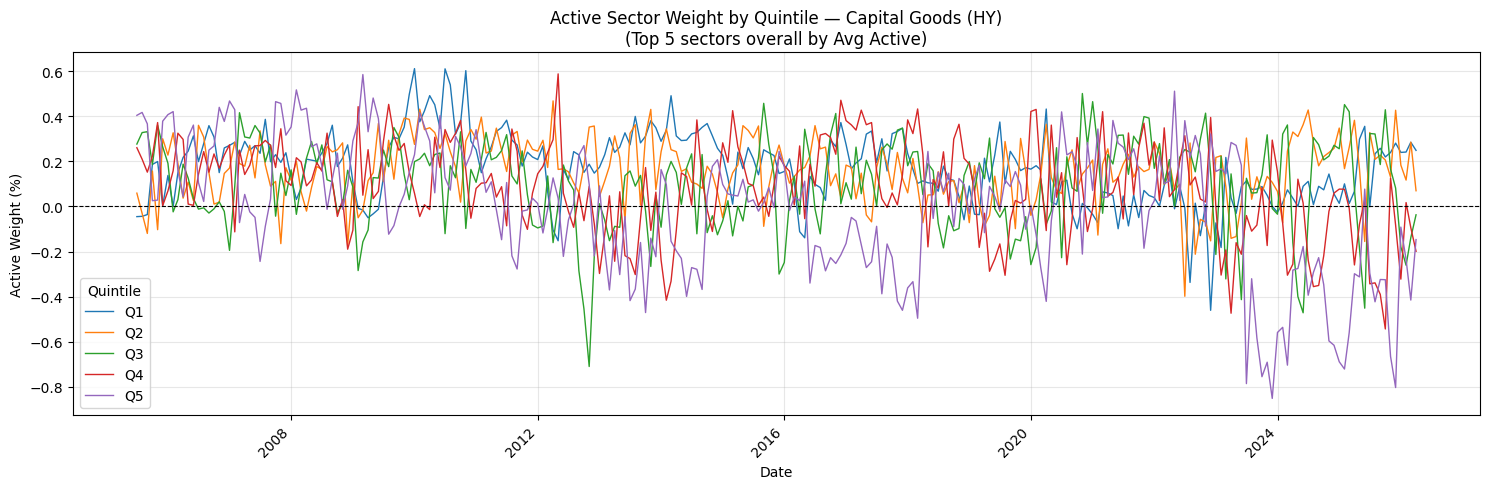


df_active_weights shape: (22290, 6)
total_active shape: (4503, 5)
Top 5 sectors overall: ['Basic Industry', 'Energy', 'Retail', 'Consumer Goods', 'Capital Goods']


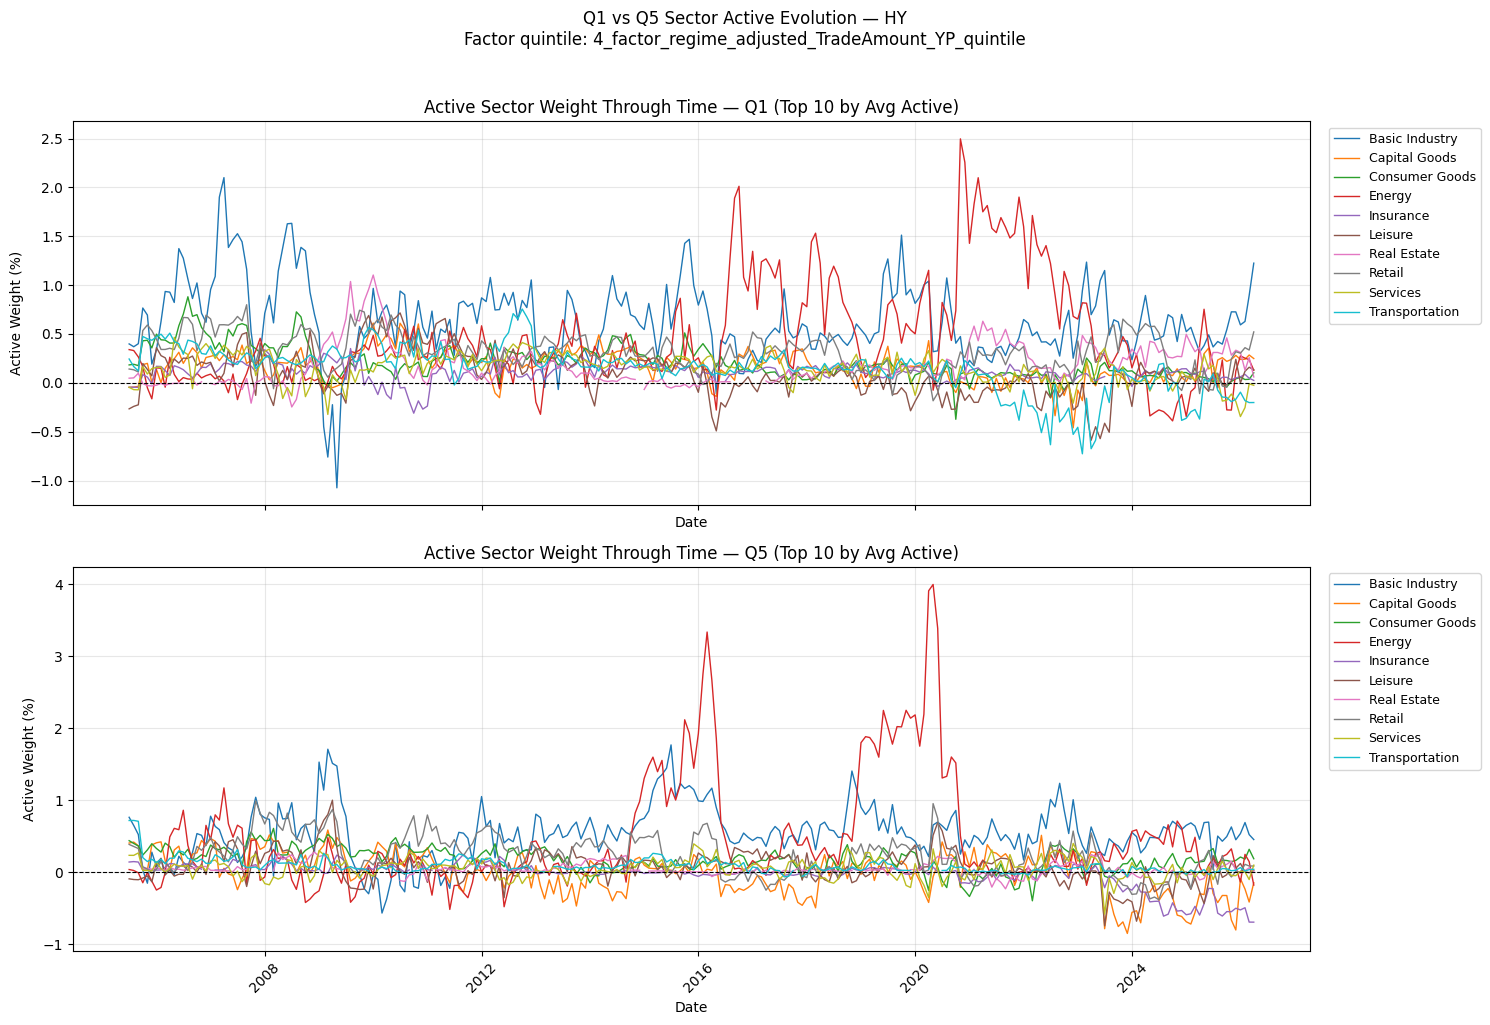

In [20]:
ACTIVE_WEIGHT_QUINTILE_COL = '4_factor_regime_adjusted_TradeAmount_YP_quintile'
SECTOR_COL = 'Industry Lvl 3 Desc'
WEIGHT_COL = '% Mkt Value'
DATE_COL = 'file_date'

QUINTILE_WEIGHT = 20.0          # portfolio has 20% per quintile
TOP_N_TOTAL = 10                # Plot 1: top 10 sectors overall
TOP_N_DETAIL = 5                # Plot 2: top 5 sectors overall

# Optional label used in titles if defined in your notebook
# INDEX_SUFFIX = "YOUR_INDEX"

# ============================================================
# 1) CLEAN / PREP
# ============================================================
df = portfolio_level_holdings.copy()

required = [DATE_COL, SECTOR_COL, ACTIVE_WEIGHT_QUINTILE_COL, WEIGHT_COL]
df = df.dropna(subset=required).copy()

df[WEIGHT_COL] = pd.to_numeric(df[WEIGHT_COL], errors='coerce')
df = df.dropna(subset=[WEIGHT_COL]).copy()

df[ACTIVE_WEIGHT_QUINTILE_COL] = df[ACTIVE_WEIGHT_QUINTILE_COL].astype(int)
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# ============================================================
# 2) STEP 1: BENCHMARK sector weight in each quintile (as-is)
#    benchmark_weight(d,q,s) = sum(% Mkt Value) for rows in (d,q,s)
# ============================================================
bmk = (
    df.groupby([DATE_COL, ACTIVE_WEIGHT_QUINTILE_COL, SECTOR_COL], as_index=False)[WEIGHT_COL]
      .sum()
      .rename(columns={WEIGHT_COL: 'benchmark_weight'})
)

# ============================================================
# 3) STEPS 2–4: PORTFOLIO weights
#    - each quintile gets 20%
#    - equal-weight by RAW ROW COUNT within each (date, quintile)
#    row_weight(d,q) = 20 / N_rows(d,q)
#    portfolio_sector_weight(d,q,s) = sum(row_weight) for rows in (d,q,s)
# ============================================================
n_in_quintile = (
    df.groupby([DATE_COL, ACTIVE_WEIGHT_QUINTILE_COL], as_index=False)
      .size()
      .rename(columns={'size': 'n_rows_in_quintile'})
)

df2 = df.merge(n_in_quintile, on=[DATE_COL, ACTIVE_WEIGHT_QUINTILE_COL], how='left')
df2['stock_port_weight'] = QUINTILE_WEIGHT / df2['n_rows_in_quintile']

port = (
    df2.groupby([DATE_COL, ACTIVE_WEIGHT_QUINTILE_COL, SECTOR_COL], as_index=False)['stock_port_weight']
       .sum()
       .rename(columns={'stock_port_weight': 'portfolio_weight'})
)

# ============================================================
# 4) STEP 5: ACTIVE weights (portfolio - benchmark)
# ============================================================
df_active_weights = (
    port.merge(bmk, on=[DATE_COL, ACTIVE_WEIGHT_QUINTILE_COL, SECTOR_COL], how='outer')
        .fillna({'portfolio_weight': 0.0, 'benchmark_weight': 0.0})
)

df_active_weights['active_weight'] = (
    df_active_weights['portfolio_weight'] - df_active_weights['benchmark_weight']
)

# ============================================================
# 5) AGGREGATE across quintiles => total active per sector per date
# ============================================================
total_active = (
    df_active_weights.groupby([DATE_COL, SECTOR_COL], as_index=False)
        .agg(
            benchmark_weight=('benchmark_weight', 'sum'),
            portfolio_weight=('portfolio_weight', 'sum'),
            active_weight=('active_weight', 'sum'),
        )
        .rename(columns={SECTOR_COL: 'sector'})
)

# ============================================================
# 6) SANITY CHECKS (optional but recommended)
# ============================================================
bmk_total_by_date = (
    bmk.groupby(DATE_COL, as_index=False)['benchmark_weight'].sum()
       .rename(columns={'benchmark_weight': 'benchmark_total'})
)

port_total_by_date = (
    df_active_weights.groupby(DATE_COL, as_index=False)['portfolio_weight'].sum()
       .rename(columns={'portfolio_weight': 'portfolio_total'})
)

# (Optional) print quick summaries
print("Benchmark total (should be ~100 each date):")
print(bmk_total_by_date['benchmark_total'].describe())

print("\nPortfolio total (should be ~100 IF all 5 quintiles exist each date):")
print(port_total_by_date['portfolio_total'].describe())

# ============================================================
# 7) PICK TOP SECTORS OVERALL by mean active through time
# ============================================================
sector_rank = (
    total_active.groupby('sector')['active_weight']
    .apply(lambda x: x.mean())
    .sort_values(ascending=False)
)

top_sectors_total = sector_rank.head(TOP_N_TOTAL).index.tolist()    # Plot 1
top_sectors_detail = sector_rank.head(TOP_N_DETAIL).index.tolist()  # Plot 2 (Top 5 overall)

# ============================================================
# 8) PLOT 1: Total active weight through time (Top N overall)
# ============================================================
pivot_active = (
    total_active[total_active['sector'].isin(top_sectors_total)]
    .pivot(index=DATE_COL, columns='sector', values='active_weight')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(15, 7))
for sector in pivot_active.columns:
    ax.plot(pivot_active.index, pivot_active[sector], label=sector, linewidth=1)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Active Weight (%)')

title_suffix = f" — {INDEX_SUFFIX}" if 'INDEX_SUFFIX' in globals() else ""
ax.set_title(
    f'Active Sector Weight Through Time (Top {TOP_N_TOTAL} by Avg Active){title_suffix}\n'
    f'Factor quintile: {ACTIVE_WEIGHT_QUINTILE_COL}'
)

ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

# ============================================================
# 9) PLOT 2: Per-quintile active weight through time for TOP 5 sectors overall
# ============================================================
for top_sector in top_sectors_detail:
    df_top_q = df_active_weights[df_active_weights[SECTOR_COL] == top_sector].copy()

    pivot_q = (
        df_top_q.pivot_table(
            index=DATE_COL,
            columns=ACTIVE_WEIGHT_QUINTILE_COL,
            values='active_weight',
            aggfunc='sum'
        )
        .sort_index()
    )

    # Keep Q1..Q5 order where available
    desired_cols = [1, 2, 3, 4, 5]
    existing_cols = [c for c in desired_cols if c in pivot_q.columns]
    pivot_q = pivot_q[existing_cols]
    pivot_q.columns = [f'Q{int(c)}' for c in pivot_q.columns]

    fig, ax = plt.subplots(figsize=(15, 5))
    pivot_q.plot(ax=ax, linewidth=1)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Date')
    ax.set_ylabel('Active Weight (%)')

    title_suffix = f" ({INDEX_SUFFIX})" if 'INDEX_SUFFIX' in globals() else ""
    ax.set_title(f'Active Sector Weight by Quintile — {top_sector}{title_suffix}\n'
                 f'(Top {TOP_N_DETAIL} sectors overall by Avg Active)')

    ax.legend(title='Quintile')
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()

print(f"\ndf_active_weights shape: {df_active_weights.shape}")
print(f"total_active shape: {total_active.shape}")
print("Top 5 sectors overall:", top_sectors_detail)


# ============================================================
# 10) PLOT 3: Active sector weight through time in Q1 and Q5
#     (Top N sectors per quintile by avg |active| through time)
# ============================================================
TOP_N_Q_EXTREMES = 10   # number of sector lines in each of Q1 and Q5 plots
EXTREME_QUINTILES = [1, 5]

# Filter to Q1 & Q5 only
df_q_ext = df_active_weights[df_active_weights[ACTIVE_WEIGHT_QUINTILE_COL].isin(EXTREME_QUINTILES)].copy()

# Rank sectors separately within Q1 and Q5 by mean active through time
rank_extremes = (
    df_q_ext.groupby([ACTIVE_WEIGHT_QUINTILE_COL, SECTOR_COL])['active_weight']
    .mean()
    .reset_index(name='mean_active')
)

top_sectors_q1 = (
    rank_extremes[rank_extremes[ACTIVE_WEIGHT_QUINTILE_COL] == 1]
    .sort_values('mean_active', ascending=False)
    .head(TOP_N_Q_EXTREMES)[SECTOR_COL]
    .tolist()
)

top_sectors_q5 = (
    rank_extremes[rank_extremes[ACTIVE_WEIGHT_QUINTILE_COL] == 5]
    .sort_values('mean_active', ascending=False)
    .head(TOP_N_Q_EXTREMES)[SECTOR_COL]
    .tolist()
)

def plot_quintile_sector_actives(df_ext, quintile, sectors, ax):
    tmp = df_ext[(df_ext[ACTIVE_WEIGHT_QUINTILE_COL] == quintile) & (df_ext[SECTOR_COL].isin(sectors))].copy()

    pivot = (
        tmp.pivot_table(index=DATE_COL, columns=SECTOR_COL, values='active_weight', aggfunc='sum')
        .sort_index()
    )

    for s in pivot.columns:
        ax.plot(pivot.index, pivot[s], label=s, linewidth=1)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Date')
    ax.set_ylabel('Active Weight (%)')
    ax.set_title(f'Active Sector Weight Through Time — Q{quintile} (Top {TOP_N_Q_EXTREMES} by Avg Active)')
    ax.grid(True, alpha=0.3)

# Create a 2-row figure: Q1 and Q5
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharex=True)

plot_quintile_sector_actives(df_q_ext, 1, top_sectors_q1, axes[0])
plot_quintile_sector_actives(df_q_ext, 5, top_sectors_q5, axes[1])

# Legends outside to the right
axes[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)

title_suffix = f" — {INDEX_SUFFIX}" if 'INDEX_SUFFIX' in globals() else ""
fig.suptitle(f'Q1 vs Q5 Sector Active Evolution{title_suffix}\nFactor quintile: {ACTIVE_WEIGHT_QUINTILE_COL}', y=1.02)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()


## 11. Chart Factor Returns

C:\Users\feme\AppData\Local\Temp\ipykernel_5396\1839052364.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['return'] * x['% Mkt Value']).sum() / x['% Mkt Value'].sum())


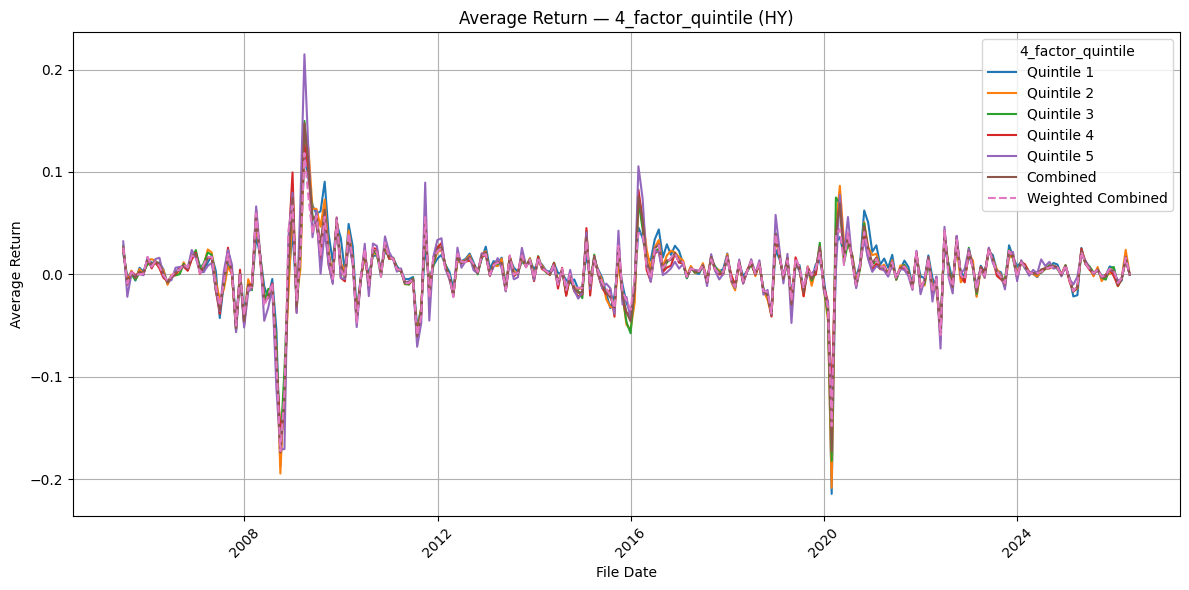

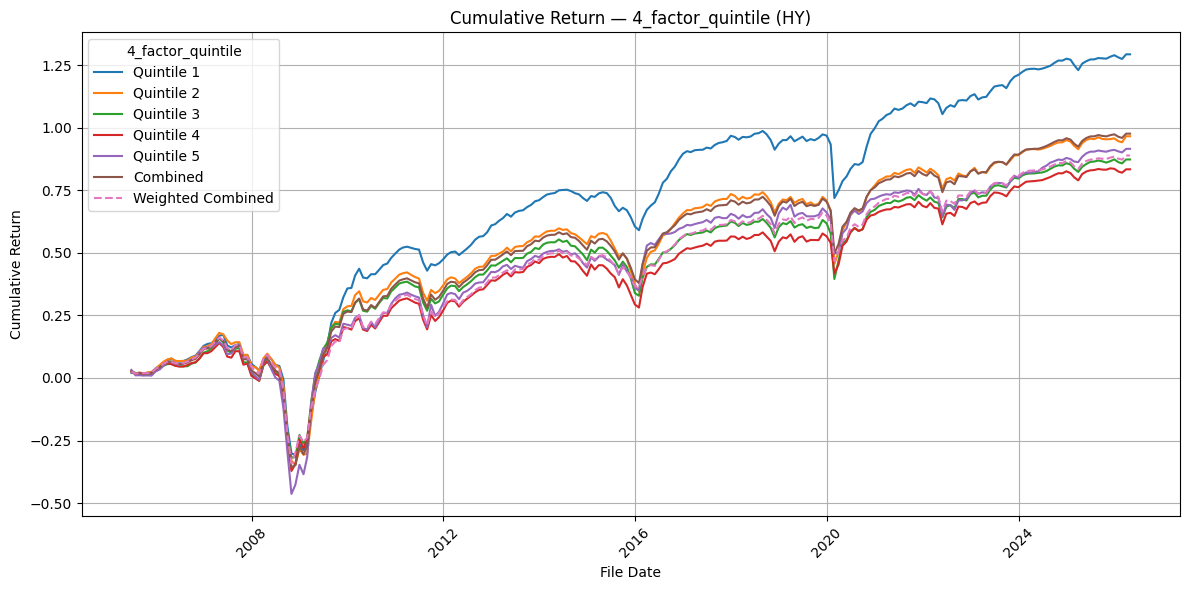

C:\Users\feme\AppData\Local\Temp\ipykernel_5396\1839052364.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['return'] * x['% Mkt Value']).sum() / x['% Mkt Value'].sum())


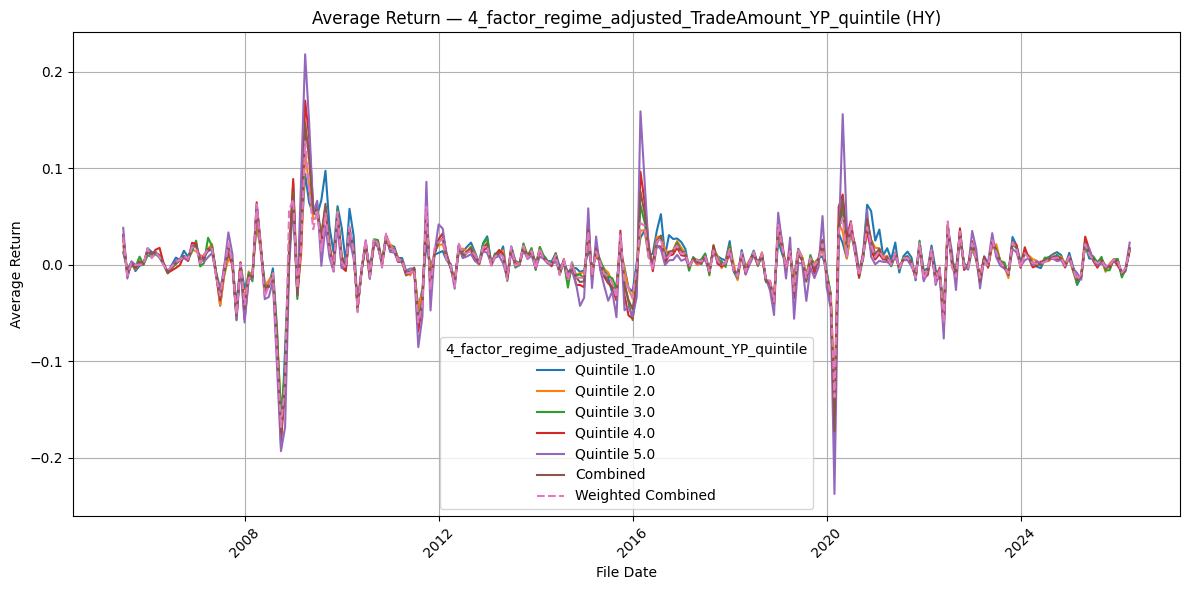

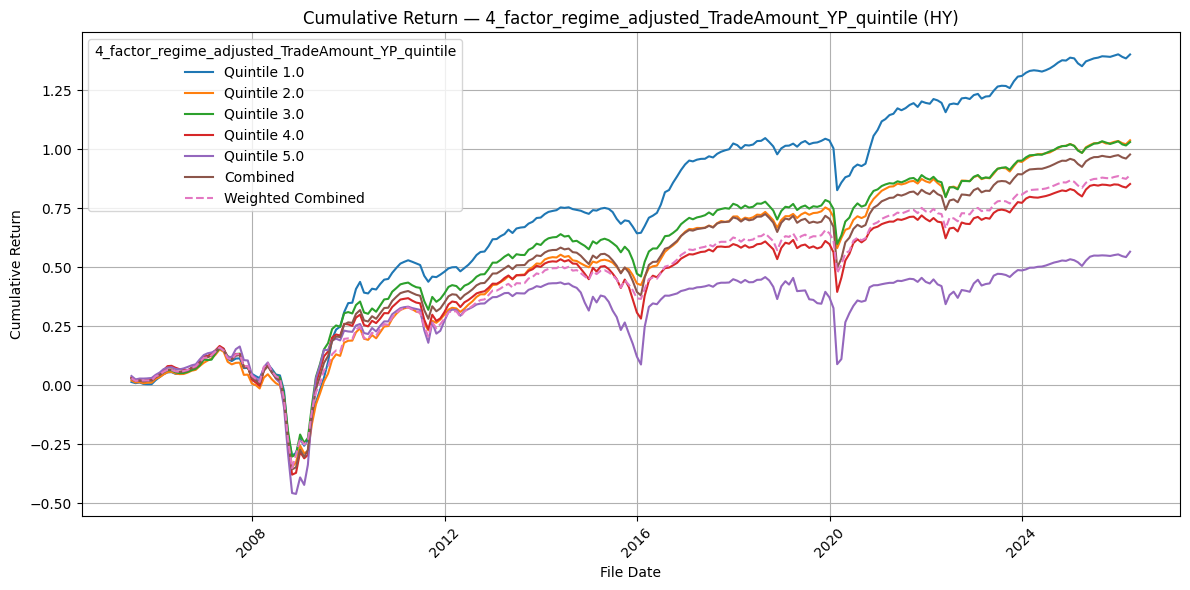

C:\Users\feme\AppData\Local\Temp\ipykernel_5396\1839052364.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['return'] * x['% Mkt Value']).sum() / x['% Mkt Value'].sum())


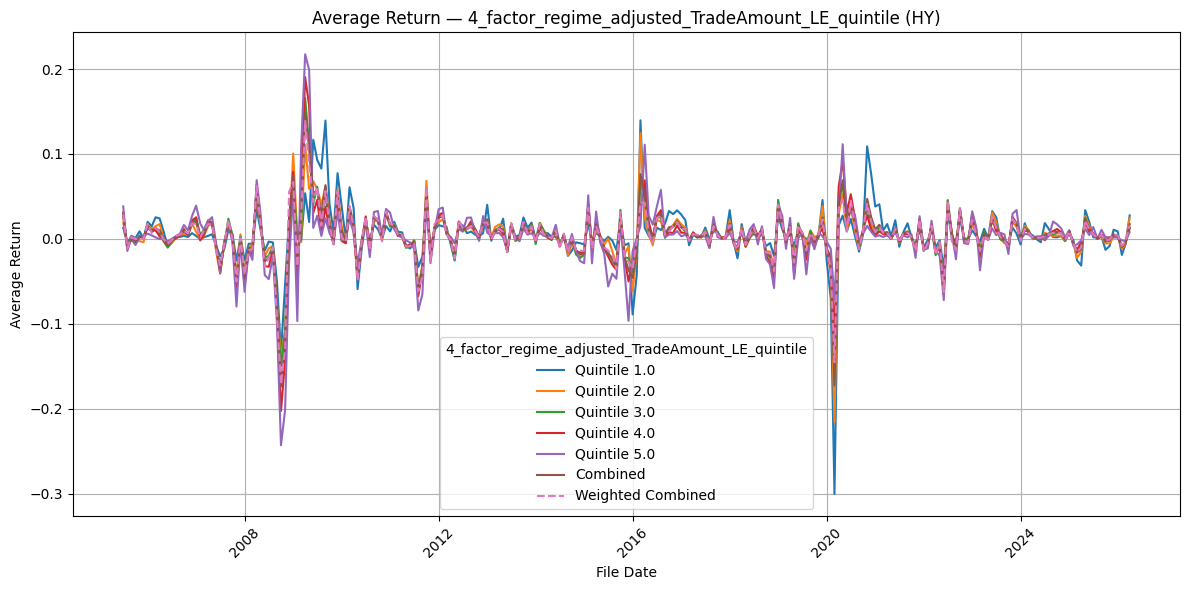

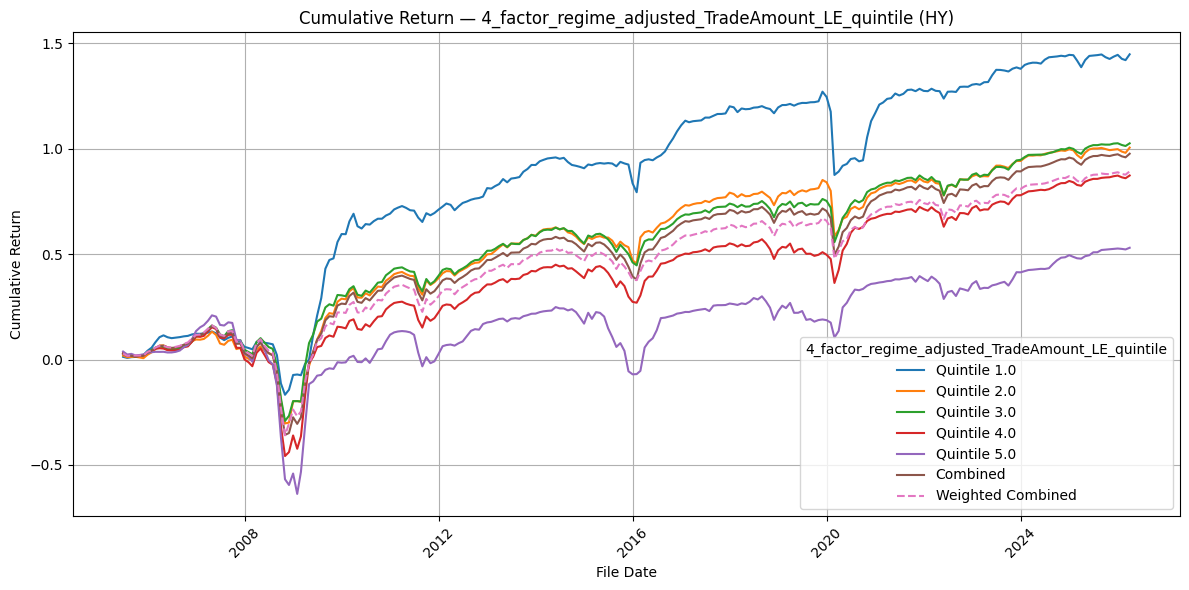

C:\Users\feme\AppData\Local\Temp\ipykernel_5396\1839052364.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['return'] * x['% Mkt Value']).sum() / x['% Mkt Value'].sum())


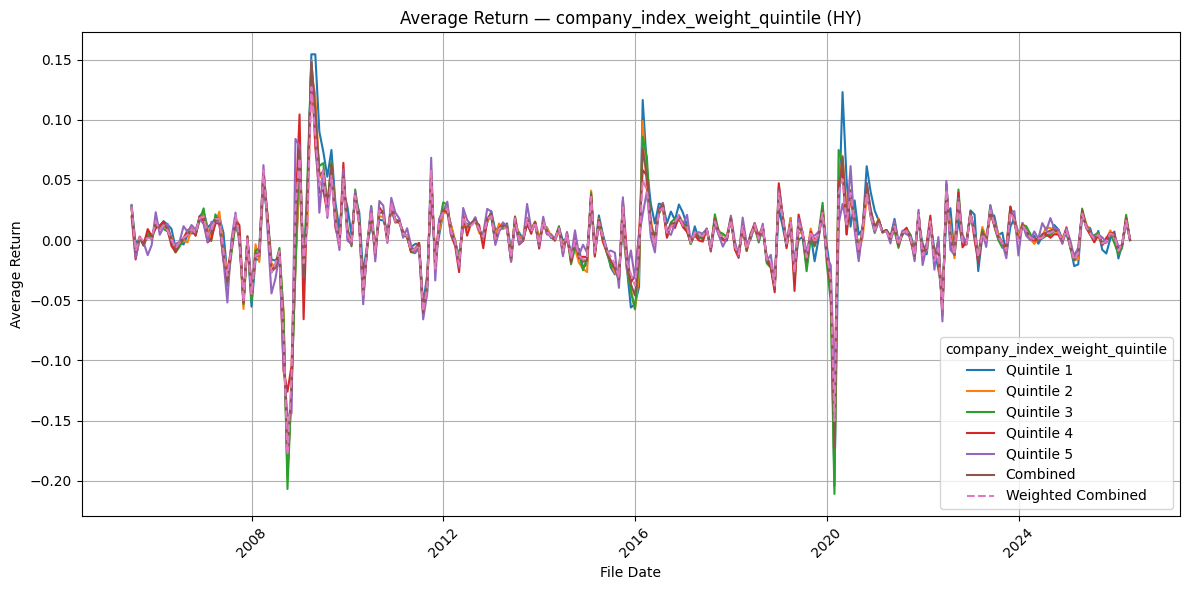

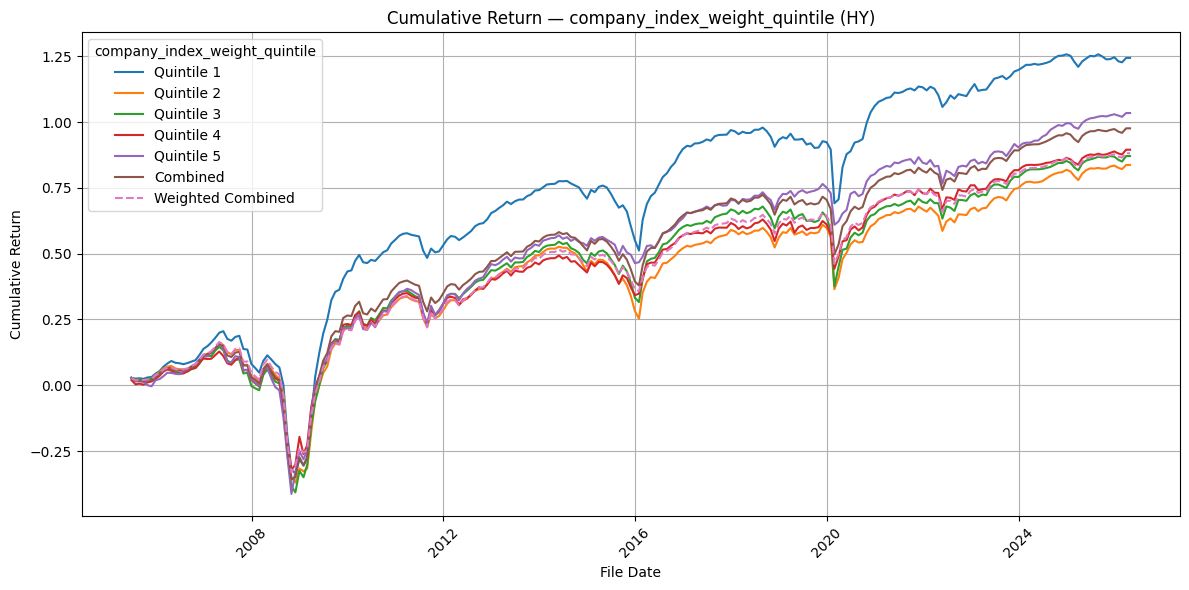

C:\Users\feme\AppData\Local\Temp\ipykernel_5396\1839052364.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['return'] * x['% Mkt Value']).sum() / x['% Mkt Value'].sum())


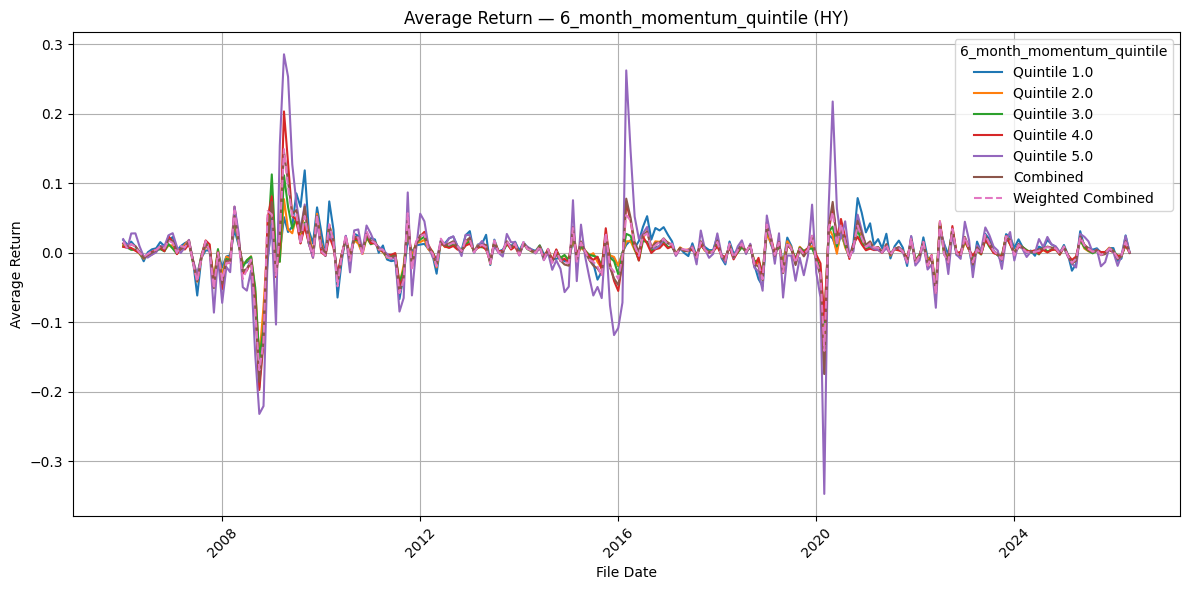

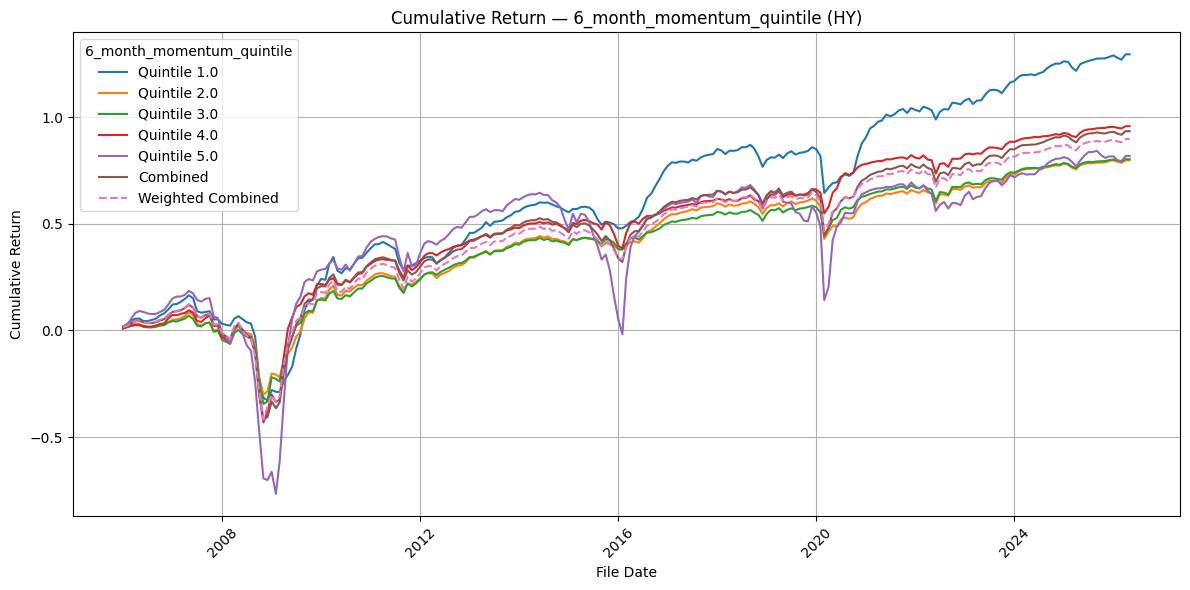

C:\Users\feme\AppData\Local\Temp\ipykernel_5396\1839052364.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['return'] * x['% Mkt Value']).sum() / x['% Mkt Value'].sum())


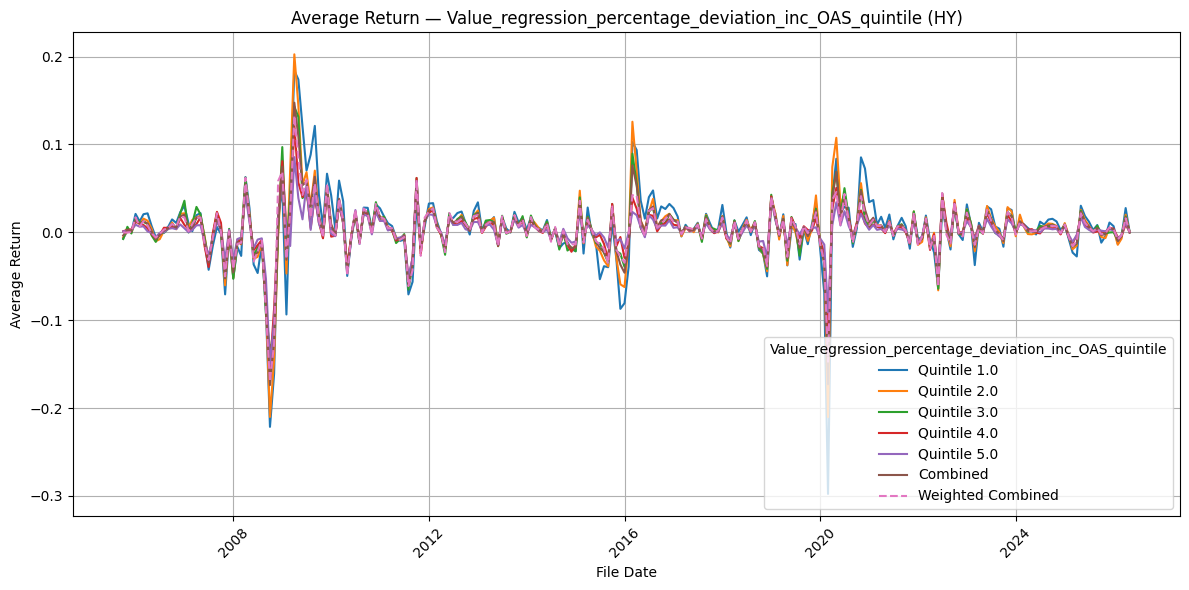

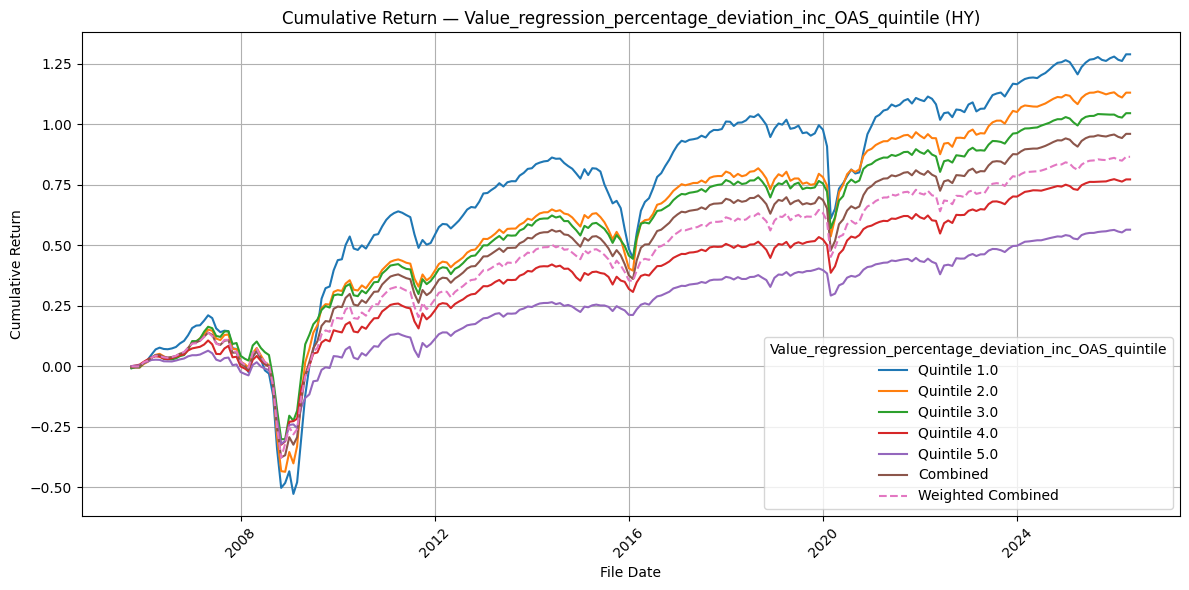

C:\Users\feme\AppData\Local\Temp\ipykernel_5396\1839052364.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['return'] * x['% Mkt Value']).sum() / x['% Mkt Value'].sum())


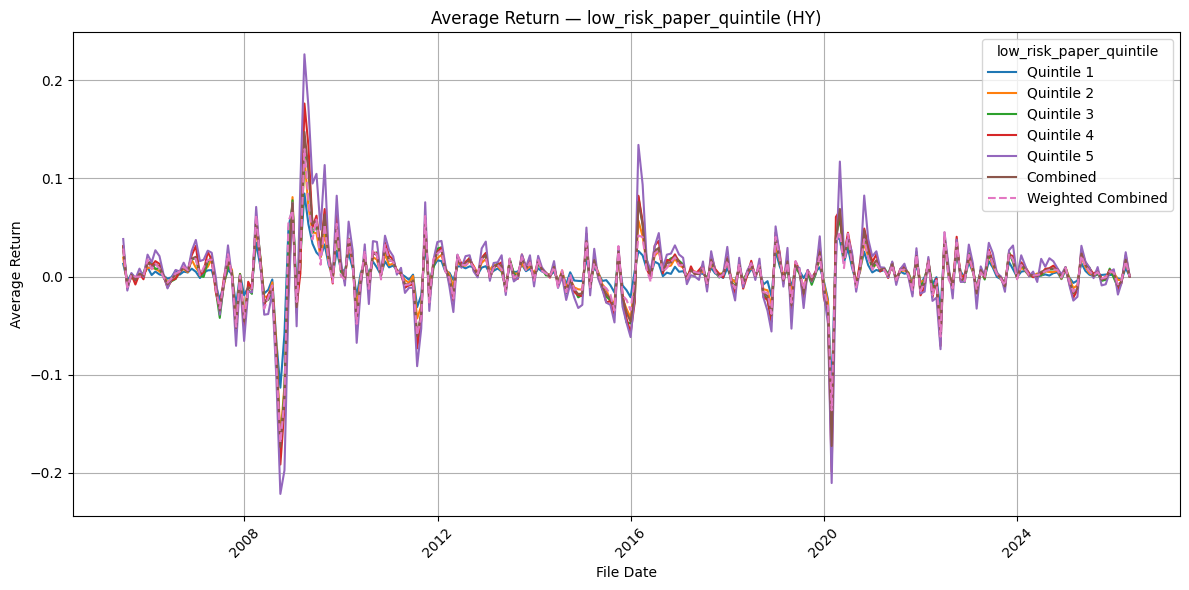

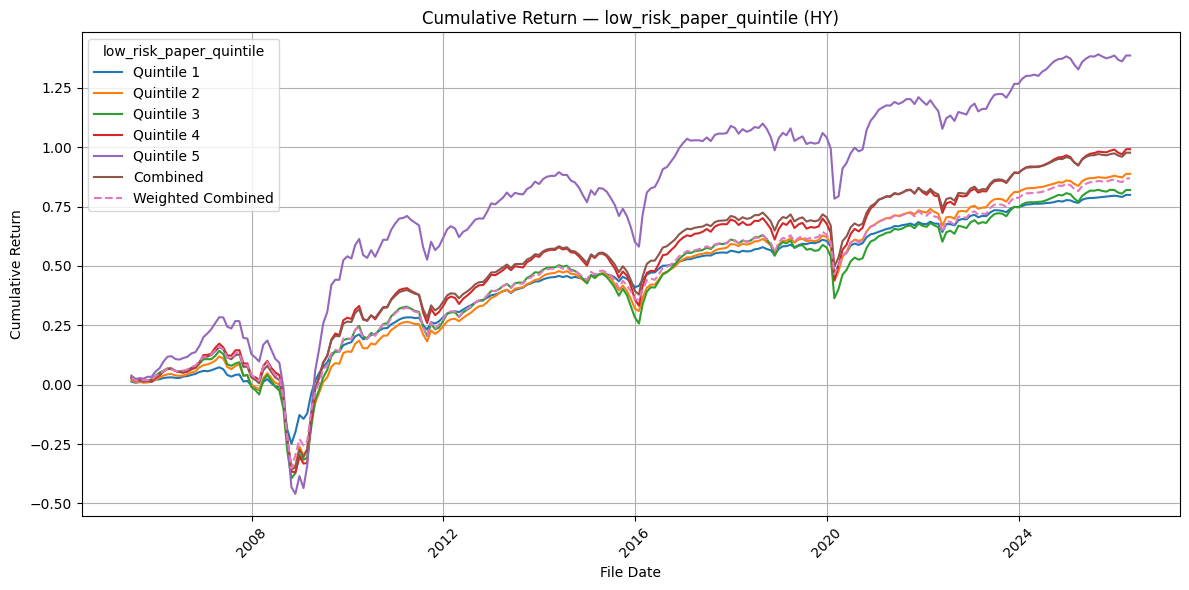

In [21]:
SAVE = False

df_chart = attach_next_month_returns(portfolio_level_holdings)
df_chart['return'] = df_chart['next_month_return'].fillna(0)

for quintile_col in QUINTILE_COLUMNS:
    df_filtered = df_chart.dropna(subset=['return', quintile_col])

    # Equal-weight average return by quintile
    avg_ret = df_filtered.groupby(['file_date', quintile_col])['return'].mean().reset_index()
    pivot_df = avg_ret.pivot(index='file_date', columns=quintile_col, values='return')
    pivot_df['Combined'] = pivot_df.mean(axis=1)

    # Market-value-weighted return by quintile
    wt_ret = (
        df_filtered.groupby(['file_date', quintile_col])
        .apply(lambda x: (x['return'] * x['% Mkt Value']).sum() / x['% Mkt Value'].sum())
        .reset_index(name='weighted_return')
    )
    wt_pivot = wt_ret.pivot(index='file_date', columns=quintile_col, values='weighted_return')
    wt_pivot['Weighted Combined'] = wt_pivot.mean(axis=1)

    # Average return over time
    plt.figure(figsize=(12, 6))
    for col in pivot_df.columns:
        label = f'Quintile {col}' if col != 'Combined' else 'Combined'
        plt.plot(pivot_df.index, pivot_df[col], label=label)
    plt.plot(wt_pivot.index, wt_pivot['Weighted Combined'], label='Weighted Combined', linestyle='--')
    plt.xlabel('File Date')
    plt.ylabel('Average Return')
    plt.title(f'Average Return \u2014 {quintile_col} ({INDEX_SUFFIX})')
    plt.legend(title=quintile_col)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    if SAVE:
        plt.savefig(f'All_{quintile_col}_returns_over_time_{INDEX_SUFFIX}.png', dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # Cumulative returns
    cum_ret = pivot_df.cumsum()
    wt_cum_ret = wt_pivot.cumsum()

    plt.figure(figsize=(12, 6))
    for col in cum_ret.columns:
        label = f'Quintile {col}' if col != 'Combined' else 'Combined'
        plt.plot(cum_ret.index, cum_ret[col], label=label)
    plt.plot(wt_cum_ret.index, wt_cum_ret['Weighted Combined'], label='Weighted Combined', linestyle='--')
    plt.xlabel('File Date')
    plt.ylabel('Cumulative Return')
    plt.title(f'Cumulative Return \u2014 {quintile_col} ({INDEX_SUFFIX})')
    plt.legend(title=quintile_col)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    if SAVE:
        plt.savefig(f'cumulative_All_{quintile_col}_returns_over_time_{INDEX_SUFFIX}.png', dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

## 12. Export Monthly Returns & Summary to Excel

### 12a. Monthly Returns by Quintile

In [22]:
output_file = f"monthly_returns_and_summary_{INDEX_SUFFIX}.xlsx"

wb = ensure_workbook(output_file)
append_regime_to_original = os.path.exists(output_file) and ("4_factor_original" in wb.sheetnames)

df_export = attach_next_month_returns(portfolio_level_holdings)
df_export["return"] = df_export["next_month_return"].fillna(0)

SHEET_START_CELL = {"4_factor_original": "A1"}
SHEET_CLEAR_PADDING = {"4_factor_original": (2500, 19)}
DEFAULT_START_CELL = "A1"
DEFAULT_CLEAR_PADDING = (2000, 50)

pivoted_data = {}
summary_table = []

for quintile_col in QUINTILE_COLUMNS:
    df_filtered = df_export.dropna(subset=["return", quintile_col])
    print(f"\u2705 Processing {quintile_col}")

    avg_ret = (
        df_filtered.groupby(["file_date", quintile_col])["return"]
        .mean()
        .reset_index()
    )
    pivot_df = avg_ret.pivot(index="file_date", columns=quintile_col, values="return")
    pivot_df["Combined"] = pivot_df.mean(axis=1)

    sheet_name = QUINTILE_RENAMES.get(quintile_col, quintile_col)[:31]
    pivoted_data[sheet_name] = pivot_df.copy()

    start_cell = SHEET_START_CELL.get(sheet_name, DEFAULT_START_CELL)
    clear_padding = SHEET_CLEAR_PADDING.get(sheet_name, DEFAULT_CLEAR_PADDING)

    upsert_table(
        wb=wb, sheet_name=sheet_name, df=pivot_df,
        start_cell=start_cell, clear=True,
        clear_padding=clear_padding, reset_index=True,
    )

    for quintile in pivot_df.columns:
        returns = pivot_df[quintile].dropna()
        summary_table.append({
            "Rating": "All",
            "Factor": QUINTILE_RENAMES.get(quintile_col, quintile_col),
            "Quintile": quintile,
            "Annualized Return": annualized_return(returns),
            "Annualized Volatility": annualized_volatility(returns),
            "Turnover": calculate_turnover(df_filtered, quintile_col),
        })

# Append regime columns to the original 4-factor sheet if it existed
if append_regime_to_original and ("4_factor_original" in pivoted_data):
    combined_regime_df = pivoted_data["4_factor_original"].copy()
    combined_regime_df.columns = [f"original_{c}" for c in combined_regime_df.columns]

    if "4_factor_YP" in pivoted_data:
        yp_df = pivoted_data["4_factor_YP"].copy()
        yp_df.columns = [f"YP_{c}" for c in yp_df.columns]
        combined_regime_df = combined_regime_df.join(yp_df, how="outer")

    if "4_factor_LE" in pivoted_data:
        le_df = pivoted_data["4_factor_LE"].copy()
        le_df.columns = [f"LE_{c}" for c in le_df.columns]
        combined_regime_df = combined_regime_df.join(le_df, how="outer")

    start_cell = SHEET_START_CELL.get("4_factor_original", DEFAULT_START_CELL)
    clear_padding = SHEET_CLEAR_PADDING.get("4_factor_original", DEFAULT_CLEAR_PADDING)
    upsert_table(
        wb=wb, sheet_name="4_factor_original", df=combined_regime_df,
        start_cell=start_cell, clear=True,
        clear_padding=clear_padding, reset_index=True,
    )

# Write summary sheet
summary_df = pd.DataFrame(summary_table)
upsert_table(
    wb=wb, sheet_name="All_Summary", df=summary_df,
    start_cell="A1", clear=True,
    clear_padding=(3000, 20), reset_index=False,
)

✅ Processing 4_factor_quintile
✅ Processing 4_factor_regime_adjusted_TradeAmount_YP_quintile
✅ Processing 4_factor_regime_adjusted_TradeAmount_LE_quintile
✅ Processing company_index_weight_quintile
✅ Processing 6_month_momentum_quintile
✅ Processing Value_regression_percentage_deviation_inc_OAS_quintile
✅ Processing low_risk_paper_quintile


### 12b. Transition Matrices

In [23]:
df_trans = portfolio_level_holdings.copy()
df_trans = df_trans.sort_values(by=['Cusip', 'file_date'])

# 1-month transitions
transition_matrices = {}
for col in QUINTILE_COLUMNS:
    if col not in df_trans.columns:
        print(f"\u26a0\ufe0f Skipping '{col}' \u2014 not found.")
        continue
    df_trans[f'{col}_next'] = df_trans.groupby('Cusip')[col].shift(-1)
    transition = pd.crosstab(df_trans[col], df_trans[f'{col}_next'], normalize='index') * 100
    transition.index.name = 'Current Quintile'
    transition.columns.name = 'Next Month Quintile'
    renamed_col = QUINTILE_RENAMES.get(col, col)
    transition_matrices[renamed_col] = transition

# Average transition summary
trans_summary = pd.DataFrame()
for renamed_col, matrix in transition_matrices.items():
    trans_summary[renamed_col] = matrix.mean(axis=0)
trans_summary = trans_summary.T
trans_summary.columns.name = 'Next Month Quintile'
trans_summary.index.name = 'Current Quintile Factor'

# Write 1-month transition matrices to workbook
ws = ensure_sheet(wb, 'Transition_Matrices')
clear_block(ws, 'A1', 3000, 20)

startrow = 1
for renamed_col, matrix in transition_matrices.items():
    ws.cell(row=startrow, column=1).value = f'Transition Matrix: {renamed_col}'
    startrow += 1
    ws.cell(row=startrow, column=1).value = matrix.index.name
    for j, col_label in enumerate(matrix.columns):
        ws.cell(row=startrow, column=2 + j).value = col_label
    startrow += 1
    for idx_val, row_data in matrix.iterrows():
        ws.cell(row=startrow, column=1).value = idx_val
        for j, val in enumerate(row_data):
            ws.cell(row=startrow, column=2 + j).value = val
        startrow += 1
    startrow += 2

# Write summary table
ws.cell(row=startrow, column=1).value = 'Average Transition Summary Table'
startrow += 1
ws.cell(row=startrow, column=1).value = trans_summary.index.name
for j, col_label in enumerate(trans_summary.columns):
    ws.cell(row=startrow, column=2 + j).value = col_label
startrow += 1
for idx_val, row_data in trans_summary.iterrows():
    ws.cell(row=startrow, column=1).value = idx_val
    for j, val in enumerate(row_data):
        ws.cell(row=startrow, column=2 + j).value = val
    startrow += 1

print("\u2705 Transition matrices (1-month) written to 'Transition_Matrices' sheet.")

# 3-month transitions
transition_matrices_3m = {}
for col in QUINTILE_COLUMNS:
    if col not in df_trans.columns:
        print(f"\u26a0\ufe0f Skipping '{col}' (3M) \u2014 not found.")
        continue
    df_trans[f'{col}_next_3m'] = df_trans.groupby('Cusip')[col].shift(-3)
    transition_3m = pd.crosstab(df_trans[col], df_trans[f'{col}_next_3m'], normalize='index') * 100
    transition_3m.index.name = 'Current Quintile'
    transition_3m.columns.name = 'Quintile in 3 Months'
    renamed_col = QUINTILE_RENAMES.get(col, col)
    transition_matrices_3m[renamed_col] = transition_3m

# Average transition summary (3-month)
trans_summary_3m = pd.DataFrame()
for renamed_col, matrix in transition_matrices_3m.items():
    trans_summary_3m[renamed_col] = matrix.mean(axis=0)
trans_summary_3m = trans_summary_3m.T
trans_summary_3m.columns.name = 'Quintile in 3 Months'
trans_summary_3m.index.name = 'Current Quintile Factor'

# Write 3-month transition matrices
ws_3m = ensure_sheet(wb, 'Transition_Matrices_3M')
clear_block(ws_3m, 'A1', 3000, 20)

startrow = 1
for renamed_col, matrix in transition_matrices_3m.items():
    ws_3m.cell(row=startrow, column=1).value = f'Transition Matrix (3M): {renamed_col}'
    startrow += 1
    ws_3m.cell(row=startrow, column=1).value = matrix.index.name
    for j, col_label in enumerate(matrix.columns):
        ws_3m.cell(row=startrow, column=2 + j).value = col_label
    startrow += 1
    for idx_val, row_data in matrix.iterrows():
        ws_3m.cell(row=startrow, column=1).value = idx_val
        for j, val in enumerate(row_data):
            ws_3m.cell(row=startrow, column=2 + j).value = val
        startrow += 1
    startrow += 2

ws_3m.cell(row=startrow, column=1).value = 'Average Transition Summary Table (3M)'
startrow += 1
ws_3m.cell(row=startrow, column=1).value = trans_summary_3m.index.name
for j, col_label in enumerate(trans_summary_3m.columns):
    ws_3m.cell(row=startrow, column=2 + j).value = col_label
startrow += 1
for idx_val, row_data in trans_summary_3m.iterrows():
    ws_3m.cell(row=startrow, column=1).value = idx_val
    for j, val in enumerate(row_data):
        ws_3m.cell(row=startrow, column=2 + j).value = val
    startrow += 1

print("\u2705 Transition matrices (3-month) written to 'Transition_Matrices_3M' sheet.")

✅ Transition matrices (1-month) written to 'Transition_Matrices' sheet.
✅ Transition matrices (3-month) written to 'Transition_Matrices_3M' sheet.


### 12c. T-Statistics (Rank–Return IC)

In [24]:
TSTAT_RANK_COLUMNS = {
    '4_factor_rank': '4_factor',
    '4_factor_regime_adjusted_TradeAmount_YP_rank': '4_factor_YP',
    '4_factor_regime_adjusted_TradeAmount_LE_rank': '4_factor_LE',
    '6_month_momentum_rank': '6_month_momentum',
    'company_index_weight_rank': 'Company_index_weight',
    'Value_regression_percentage_deviation_inc_OAS_rank': 'Value_Rating_Maturity_OAS',
    'low_risk_paper_rank': 'low_risk_paper',
}

df_tstat = df_export.copy()
tstat_results = []
monthly_corr_series = {}

for rank_col, display_name in TSTAT_RANK_COLUMNS.items():
    if rank_col not in df_tstat.columns:
        print(f"\u26a0\ufe0f Skipping '{rank_col}' for T-stat \u2014 not found.")
        continue

    monthly_corrs = (
        df_tstat.dropna(subset=[rank_col, 'next_month_return'])
        .groupby('file_date')
        .apply(lambda g: g[rank_col].corr(g['next_month_return']) if len(g) > 2 else np.nan)
    )
    monthly_corrs = monthly_corrs.dropna()
    if monthly_corrs.empty:
        continue

    monthly_corr_series[display_name] = monthly_corrs

    mean_ic = monthly_corrs.mean()
    std_ic = monthly_corrs.std()
    n_months = len(monthly_corrs)
    t_stat = mean_ic / (std_ic / np.sqrt(n_months)) if std_ic > 0 else np.nan

    tstat_results.append({
        'Factor': display_name,
        'Mean Correlation (IC)': mean_ic,
        'Std Dev of Correlations': std_ic,
        'N Months': n_months,
        'T-Statistic': t_stat,
    })

tstat_summary_df = pd.DataFrame(tstat_results)

monthly_corr_pivot = (
    pd.DataFrame(monthly_corr_series) if monthly_corr_series else pd.DataFrame()
)
if not monthly_corr_pivot.empty:
    monthly_corr_pivot.index.name = 'file_date'

# Write to worksheet
ws_tstat = ensure_sheet(wb, 'T_Statistics')
clear_block(ws_tstat, 'A1', 5000, 30)

startrow = 1
ws_tstat.cell(row=startrow, column=1).value = 'T-Statistic Summary (Rank vs Following Month Return)'
startrow += 2

for j, col_name in enumerate(tstat_summary_df.columns):
    ws_tstat.cell(row=startrow, column=1 + j).value = col_name
startrow += 1

for _, row_data in tstat_summary_df.iterrows():
    for j, val in enumerate(row_data):
        ws_tstat.cell(row=startrow, column=1 + j).value = val
    startrow += 1

startrow += 2
ws_tstat.cell(row=startrow, column=1).value = 'Monthly Rank-Return Correlations by Factor'
startrow += 2

if not monthly_corr_pivot.empty:
    ws_tstat.cell(row=startrow, column=1).value = 'file_date'
    for j, col_name in enumerate(monthly_corr_pivot.columns):
        ws_tstat.cell(row=startrow, column=2 + j).value = col_name
    startrow += 1
    for dt, row_data in monthly_corr_pivot.iterrows():
        ws_tstat.cell(row=startrow, column=1).value = dt
        for j, val in enumerate(row_data):
            ws_tstat.cell(row=startrow, column=2 + j).value = val
        startrow += 1

print("\u2705 T-Statistics written to 'T_Statistics' sheet.")
print(tstat_summary_df.to_string(index=False))

C:\Users\feme\AppData\Local\Temp\ipykernel_5396\4215182557.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[rank_col].corr(g['next_month_return']) if len(g) > 2 else np.nan)
C:\Users\feme\AppData\Local\Temp\ipykernel_5396\4215182557.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[rank_col].corr(g['next_month_return']) if len(g) > 2 else np.nan)
C:\Users\feme\AppData\Loca

✅ T-Statistics written to 'T_Statistics' sheet.
                   Factor  Mean Correlation (IC)  Std Dev of Correlations  N Months  T-Statistic
                 4_factor              -0.026101                 0.104646       250    -3.943723
              4_factor_YP              -0.039479                 0.119893       250    -5.206446
              4_factor_LE              -0.026075                 0.172624       250    -2.388295
         6_month_momentum              -0.026008                 0.143436       250    -2.866953
     Company_index_weight              -0.005424                 0.097069       250    -0.883557
Value_Rating_Maturity_OAS              -0.026175                 0.124931       250    -3.312733
           low_risk_paper               0.012215                 0.160532       250     1.203090


### 12e. Backtesting Analytics

In [25]:

# ── Compute monthly cap-weighted benchmark return ─────────────────────────────
bm_df = portfolio_level_holdings.copy()
bm_df['% Mkt Value'] = pd.to_numeric(bm_df['% Mkt Value'], errors='coerce')
benchmark_monthly = (
    bm_df.groupby('file_date')
    .apply(lambda g: (g['% Mkt Value'].fillna(0) / 100 * g['Excess Return % MTD'].fillna(0)).sum(),
           include_groups=False)
    .rename('benchmark_return')
)

# ── Helper analytics functions ────────────────────────────────────────────────
def _max_drawdown(returns):
    cum = (1 + returns).cumprod()
    drawdown = (cum - cum.cummax()) / cum.cummax()
    return drawdown.min()


def _sharpe(returns, periods_per_year=12):
    ann_vol = annualized_volatility(returns)
    return annualized_return(returns) / ann_vol if ann_vol != 0 else np.nan


def _alpha_beta(port, bench):
    df_reg = pd.DataFrame({'p': port, 'b': bench}).dropna()
    if len(df_reg) < 3:
        return np.nan, np.nan
    model = sm.OLS(df_reg['p'], sm.add_constant(df_reg['b'])).fit()
    alpha_ann = (1 + model.params['const']) ** 12 - 1
    return alpha_ann, model.params['b']


def _capture(port, bench, upside=True):
    mask = bench > 0 if upside else bench < 0
    if mask.sum() < 2:
        return np.nan
    bm_val = annualized_return(bench[mask])
    return annualized_return(port[mask]) / bm_val if bm_val != 0 else np.nan


# ── Compute analytics for every factor × quintile ────────────────────────────
analytics_records = []

for quintile_col in QUINTILE_COLUMNS:
    factor_name = QUINTILE_RENAMES.get(quintile_col, quintile_col)
    sheet_key = factor_name[:31]
    if sheet_key not in pivoted_data:
        print(f"⚠️  {sheet_key} not in pivoted_data — skipping.")
        continue

    pivot_df = pivoted_data[sheet_key]

    for quintile in pivot_df.columns:
        port_series = pivot_df[quintile].dropna()
        common = port_series.index.intersection(benchmark_monthly.index)
        if len(common) < 3:
            continue
        port = port_series.loc[common]
        bench = benchmark_monthly.loc[common]
        active = port - bench
        alpha_ann, beta = _alpha_beta(port, bench)

        analytics_records.append({
            'Factor': factor_name,
            'Quintile': quintile,
            'Annualized Active Return': annualized_return(active),
            'Tracking Error Volatility': annualized_volatility(active),
            'Sharpe Ratio': _sharpe(port),
            'Maximum Drawdown': _max_drawdown(port),
            'Alpha (Annualized)': alpha_ann,
            'Beta to Benchmark': beta,
            'Upside Capture': _capture(port, bench, upside=True),
            'Downside Capture': _capture(port, bench, upside=False),
            'Correlation vs Benchmark': port.corr(bench),
        })

analytics_df = pd.DataFrame(analytics_records)
upsert_table(
    wb=wb, sheet_name='Backtest_Analytics', df=analytics_df,
    start_cell='A1', clear=True,
    clear_padding=(2000, 20), reset_index=False,
)
print("✅ Backtest analytics written to 'Backtest_Analytics' sheet.")
display(analytics_df.head())

✅ Backtest analytics written to 'Backtest_Analytics' sheet.


,Factor,Quintile,Annualized Active Return,Tracking Error Volatility,Sharpe Ratio,Maximum Drawdown,Alpha (Annualized),Beta to Benchmark,Upside Capture,Downside Capture,Correlation vs Benchmark
0,4_factor_original,1,-0.006128,0.103635,0.575485,-0.400676,0.033002,0.468966,0.566251,0.329218,0.450169
1,4_factor_original,2,-0.022250,0.110284,0.375989,-0.431307,0.016282,0.479997,0.473257,0.380956,0.427743
2,4_factor_original,3,-0.027018,0.115120,0.358247,-0.397433,0.019393,0.360160,0.360986,0.223443,0.337911
3,4_factor_original,4,-0.028566,0.112535,0.353287,-0.420438,0.017558,0.358935,0.304862,0.135947,0.346882
4,4_factor_original,5,-0.026266,0.126027,0.314035,-0.480737,0.018526,0.406244,0.331004,0.160700,0.330688


### 12d. Save Workbook

In [26]:
wb.save(output_file)
print(f"\u2705 Workbook saved: {output_file}")

✅ Workbook saved: monthly_returns_and_summary_HY.xlsx


## 13. Export Historical Screens to Excel

In [27]:
EXPORT_DATES = None  # set to a list of pd.Timestamps to export specific dates

# Compute percentile ranks for each 4-factor variant
for rank_col, pct_col in [
    ('4_factor_rank', 'percentile_rank_4_factor'),
    ('4_factor_regime_adjusted_TradeAmount_YP_rank', 'percentile_rank_4_factor_regime_adjusted_TradeAmount_YP'),
    ('4_factor_regime_adjusted_TradeAmount_LE_rank', 'percentile_rank_4_factor_regime_adjusted_TradeAmount_LE'),
]:
    portfolio_level_holdings[pct_col] = (
        portfolio_level_holdings.groupby('file_date')[rank_col]
        .rank(pct=True) * 100
    ).fillna(0).round(0).astype(int)

# Write one sheet per month
fixed_income_output_path = f"{INDEX_SUFFIX} Ranks for JG.xlsx"
sheets_written = 0

with pd.ExcelWriter(fixed_income_output_path, engine='openpyxl') as writer:
    dates_to_export = EXPORT_DATES if EXPORT_DATES else sorted(portfolio_level_holdings['file_date'].unique())
    for file_date in dates_to_export:
        if file_date > CUTOFF_DATE:
            subset = portfolio_level_holdings[portfolio_level_holdings['file_date'] == file_date]
            if not subset.empty:
                subset.reindex(columns=EXPORT_COLUMNS).to_excel(
                    writer, sheet_name=clean_sheet_name(file_date.strftime('%Y-%m-%d')), index=False,
                )
                sheets_written += 1

    if sheets_written == 0:
        pd.DataFrame({'Message': ['No data after cutoff']}).to_excel(writer, sheet_name='No Data', index=False)

print(f"\u2705 Exported {sheets_written} sheets to {fixed_income_output_path}")

✅ Exported 244 sheets to HY Ranks for JG.xlsx


## 14. OAS by Quintile Analysis
Calculate average OAS for each factor quintile over time.

In [28]:
OAS_QUINTILE_COLUMNS = [
    'company_index_weight_quintile',
    'Value_regression_percentage_deviation_inc_OAS_quintile',
    '4_factor_quintile',
    '6_month_momentum_quintile',
    'low_risk_paper_quintile',
]

OAS_COL = 'oas'
DATE_COL = 'file_date'

data = portfolio_level_holdings.copy()
data[OAS_COL] = pd.to_numeric(data[OAS_COL], errors='coerce')
data[DATE_COL] = pd.to_datetime(data[DATE_COL], errors='coerce').dt.date
data = data.dropna(subset=[DATE_COL])

universe_by_date = data.groupby(DATE_COL)[OAS_COL].mean()
all_results = []

for factor_col in OAS_QUINTILE_COLUMNS:
    if factor_col not in data.columns:
        print(f"Skipping '{factor_col}' \u2014 not found.")
        continue

    qser = pd.to_numeric(data[factor_col], errors='coerce')
    valid = data.loc[qser.isin([1, 2, 3, 4, 5])].copy()
    if valid.empty:
        continue
    valid['__q__'] = qser.loc[valid.index]

    by_q = valid.groupby([DATE_COL, '__q__'])[OAS_COL].mean().reset_index()
    for _, r in by_q.iterrows():
        all_results.append({
            'FactorQuintileColumn': factor_col,
            'FileDate': r[DATE_COL],
            'Quintile': f"Q{int(r['__q__'])}",
            'OAS': r[OAS_COL],
        })

    # Q5 - Q1 spread
    pivot = by_q.pivot(index=DATE_COL, columns='__q__', values=OAS_COL)
    for d in pivot.index:
        q1 = pivot.loc[d, 1] if 1 in pivot.columns else np.nan
        q5 = pivot.loc[d, 5] if 5 in pivot.columns else np.nan
        all_results.append({
            'FactorQuintileColumn': factor_col,
            'FileDate': d,
            'Quintile': 'Q5 - Q1',
            'OAS': (q5 - q1) if pd.notna(q5) and pd.notna(q1) else np.nan,
        })

    # Universe average
    for d, mean_val in universe_by_date.items():
        all_results.append({
            'FactorQuintileColumn': factor_col,
            'FileDate': d,
            'Quintile': 'Universe',
            'OAS': mean_val,
        })

average_oas_by_factor = pd.DataFrame(all_results)
print(average_oas_by_factor)

# Export
out_path = Path(r"C:\PSA\Code\Fixed Income Model\Output")
out_path.mkdir(parents=True, exist_ok=True)
file_path = out_path / f"Average_oas_by_factor_quintile_{INDEX_SUFFIX}_{datetime.now():%Y%m%d}.xlsx"

ORDER_KEY = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4, 'Q5': 5, 'Universe': 6, 'Q5 - Q1': 7}

with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    average_oas_by_factor.to_excel(writer, sheet_name='Combined', index=False)

    for factor_col, subdf in average_oas_by_factor.groupby('FactorQuintileColumn', dropna=False):
        ordered = subdf.copy()
        ordered['__order__'] = ordered['Quintile'].map(ORDER_KEY).fillna(99)
        ordered = ordered.sort_values(['FileDate', '__order__']).drop(columns='__order__')
        sheet = clean_sheet_name(factor_col)
        ordered.to_excel(writer, sheet_name=sheet, index=False)

print(f"Saved: {file_path}")

               FactorQuintileColumn    FileDate  Quintile         OAS
0     company_index_weight_quintile  2005-06-30        Q1  618.270886
1     company_index_weight_quintile  2005-06-30        Q2  441.250633
2     company_index_weight_quintile  2005-06-30        Q3  404.589873
3     company_index_weight_quintile  2005-06-30        Q4  459.732997
4     company_index_weight_quintile  2005-06-30        Q5  366.826972
...                             ...         ...       ...         ...
8726        low_risk_paper_quintile  2025-12-31  Universe  365.676379
8727        low_risk_paper_quintile  2026-01-31  Universe  370.968882
8728        low_risk_paper_quintile  2026-02-28  Universe  393.502119
8729        low_risk_paper_quintile  2026-03-31  Universe  415.784469
8730        low_risk_paper_quintile  2026-04-30  Universe  366.004253

[8731 rows x 4 columns]
Saved: C:\PSA\Code\Fixed Income Model\Output\Average_oas_by_factor_quintile_HY_20260520.xlsx


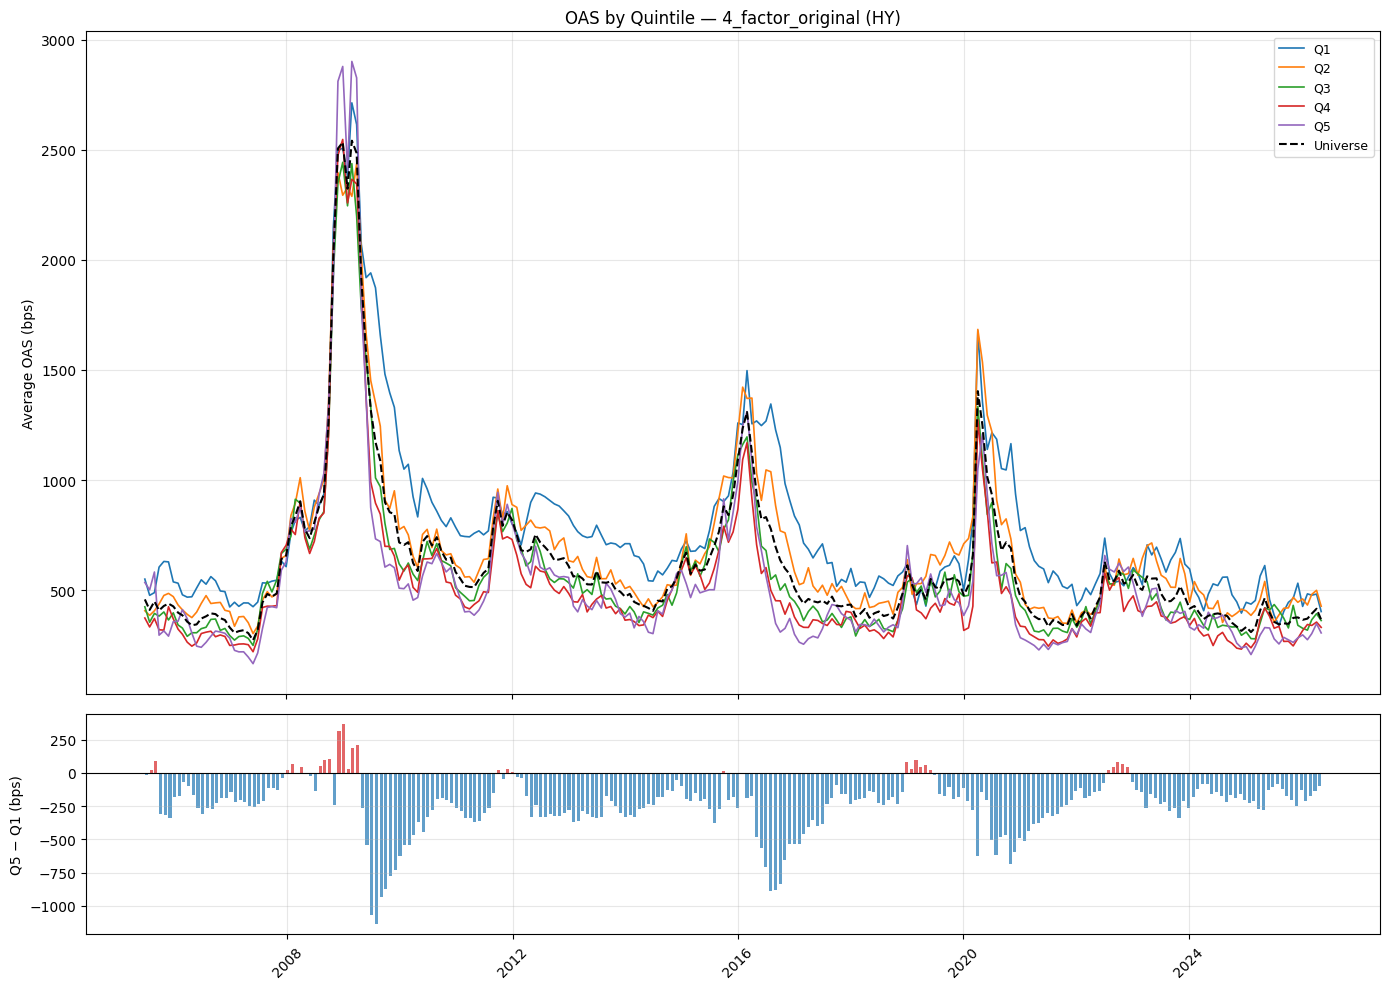

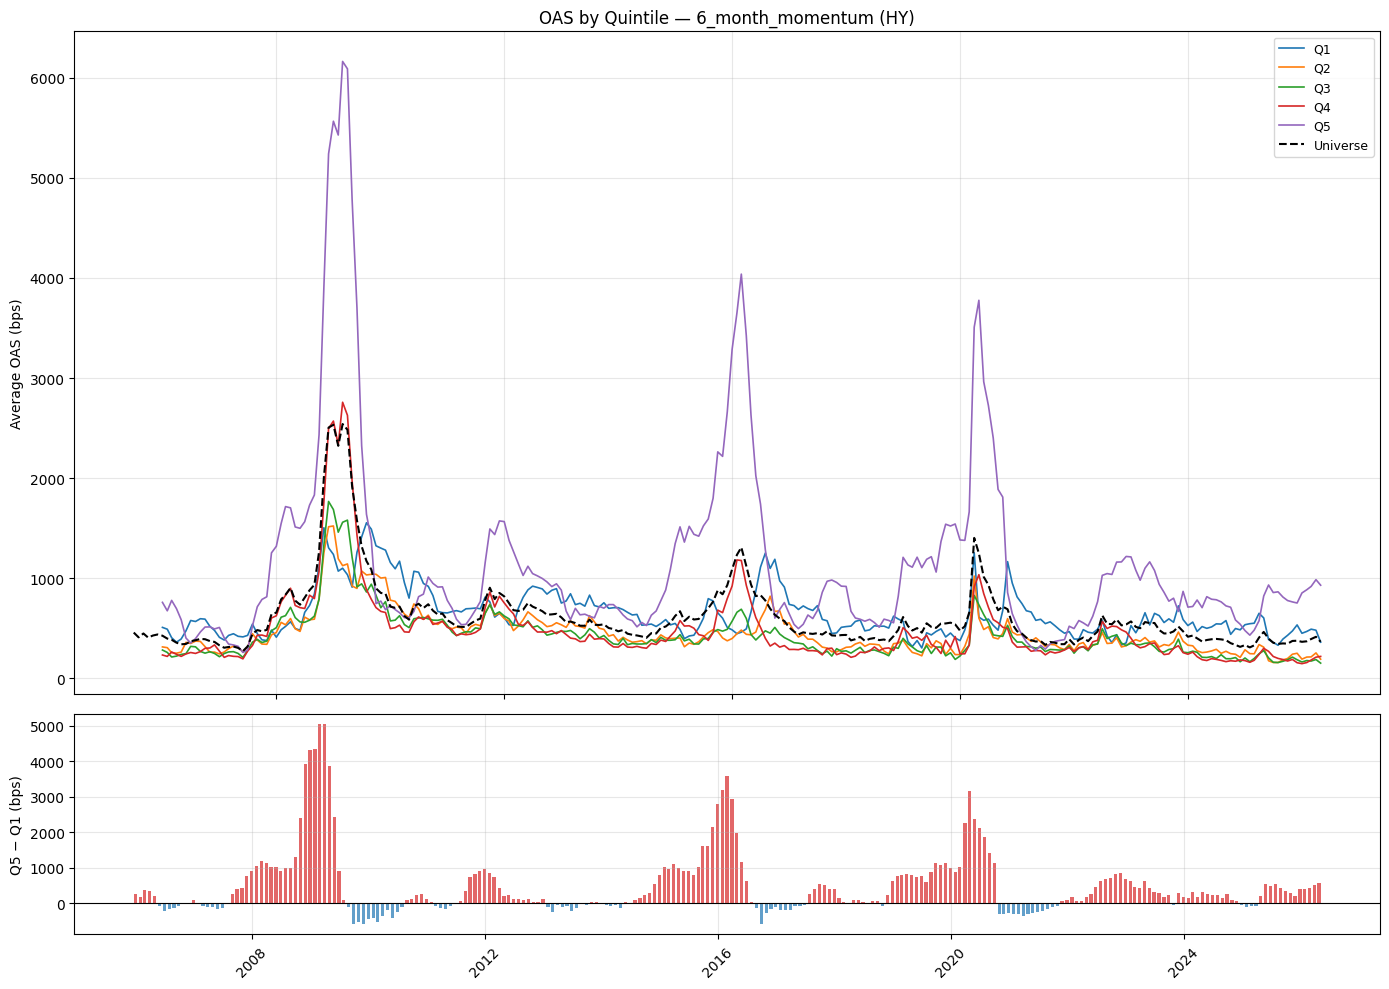

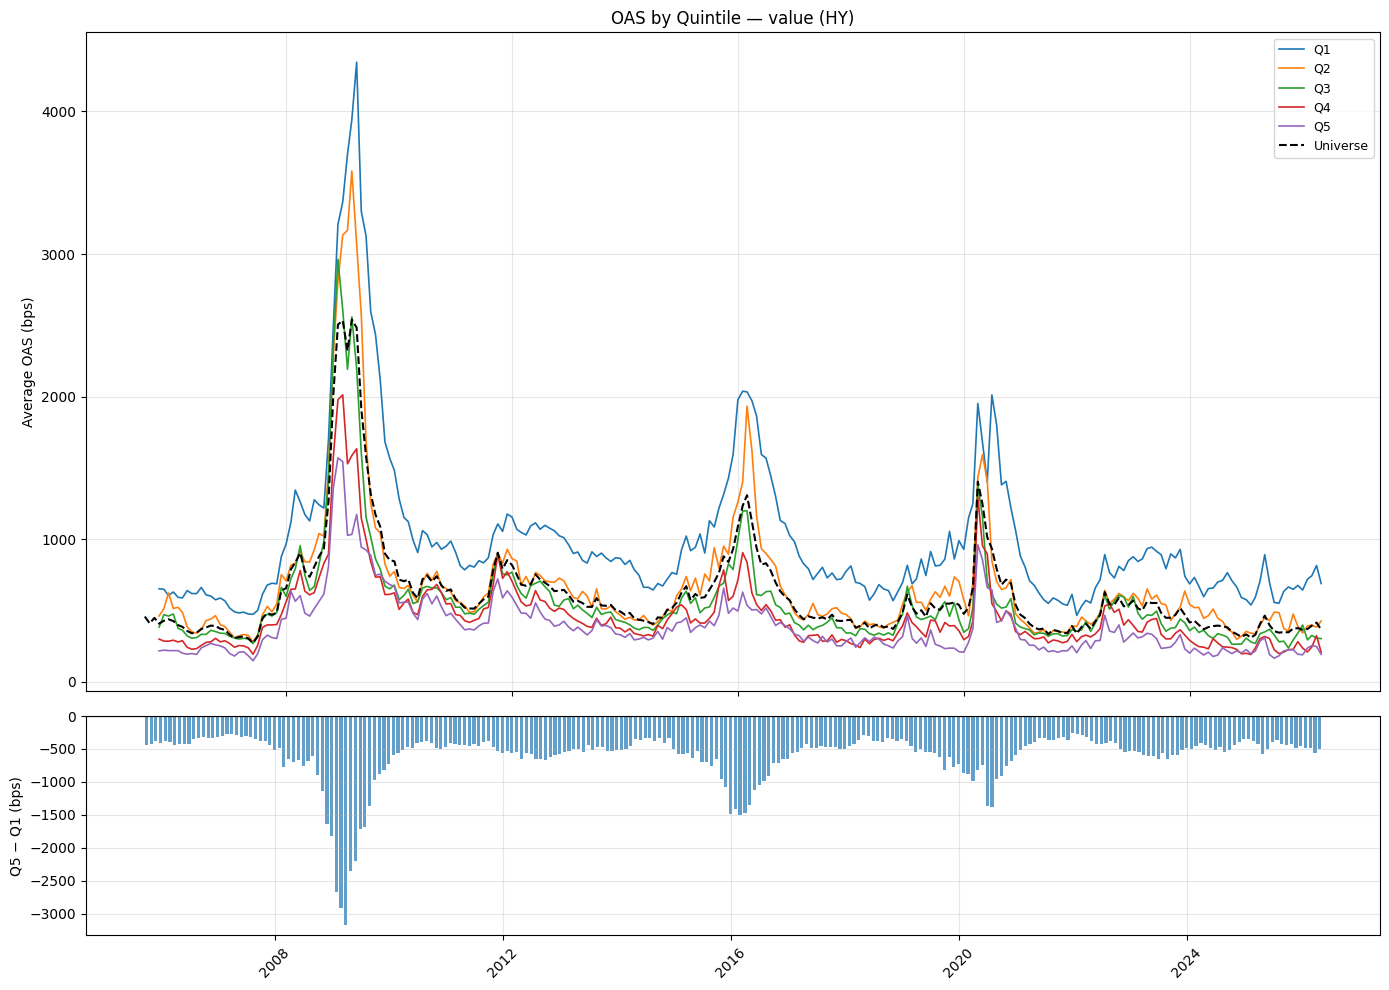

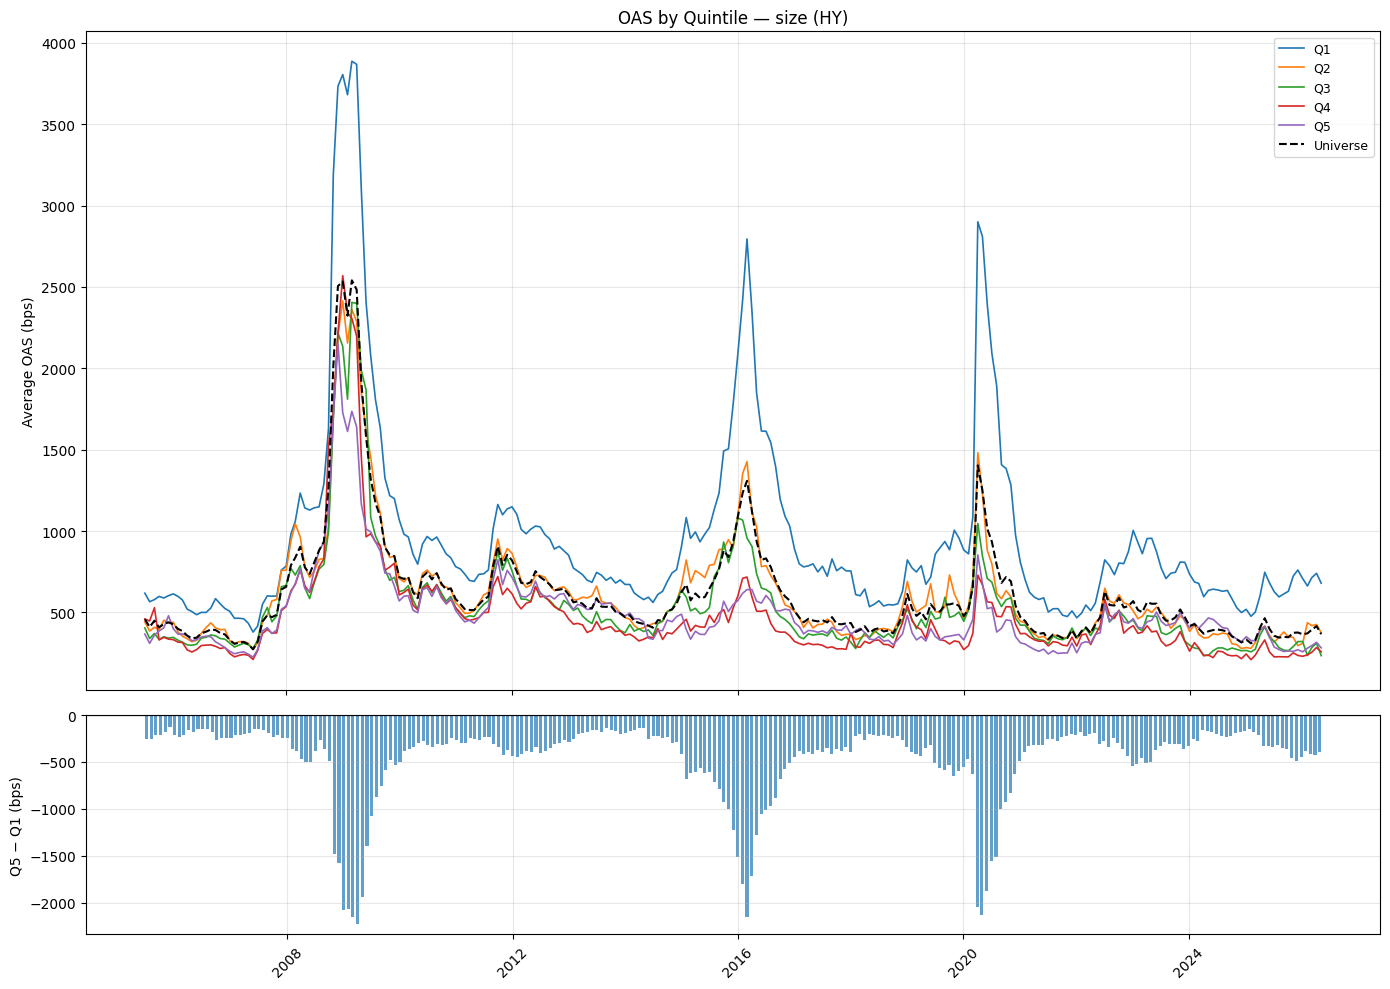

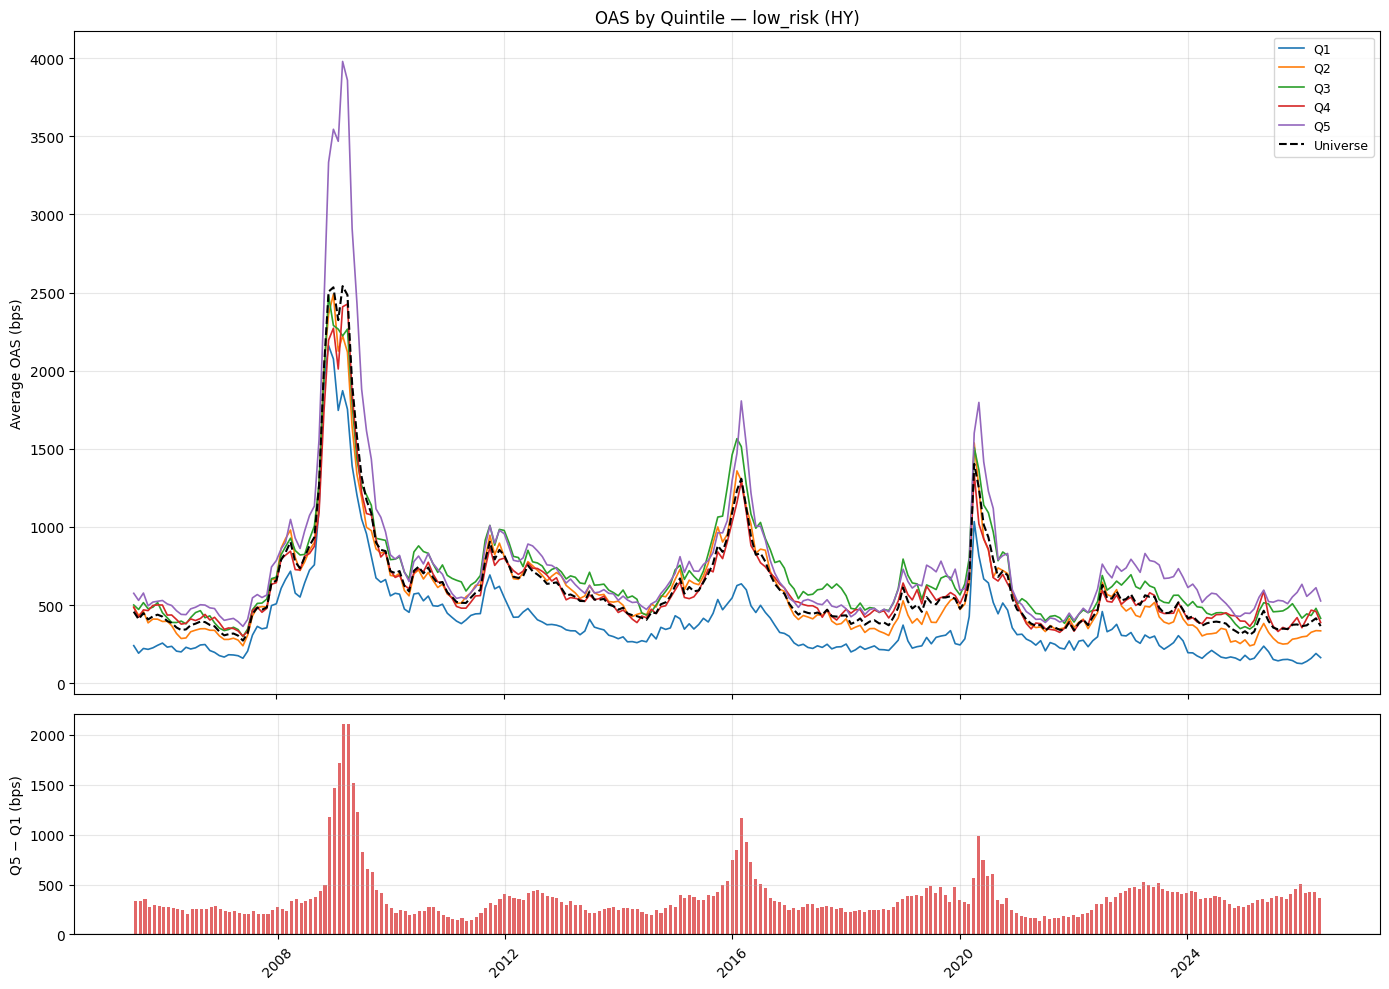

In [29]:

QUINTILE_ORDER = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Universe', 'Q5 - Q1']
QUINTILE_COLORS = {
    'Q1': '#1f77b4', 'Q2': '#ff7f0e', 'Q3': '#2ca02c',
    'Q4': '#d62728', 'Q5': '#9467bd',
    'Universe': 'black', 'Q5 - Q1': 'grey',
}
QUINTILE_STYLES = {'Universe': '--', 'Q5 - Q1': ':'}

for factor_col, subdf in average_oas_by_factor.groupby('FactorQuintileColumn'):
    pivot = (
        subdf.pivot(index='FileDate', columns='Quintile', values='OAS')
        .sort_index()
    )
    cols = [c for c in QUINTILE_ORDER if c in pivot.columns]
    pivot = pivot[cols]

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

    ax_main, ax_spread = axes

    for q in [c for c in cols if c not in ('Q5 - Q1', 'Universe')]:
        ax_main.plot(
            pivot.index, pivot[q],
            label=q, color=QUINTILE_COLORS.get(q),
            linewidth=1.2,
        )
    if 'Universe' in pivot.columns:
        ax_main.plot(
            pivot.index, pivot['Universe'],
            label='Universe', color=QUINTILE_COLORS['Universe'],
            linestyle='--', linewidth=1.5,
        )

    ax_main.set_ylabel('Average OAS (bps)')
    ax_main.set_title(f'OAS by Quintile — {QUINTILE_RENAMES.get(factor_col, factor_col)} ({INDEX_SUFFIX})')
    ax_main.legend(loc='upper right', fontsize=9)
    ax_main.grid(True, alpha=0.3)
    ax_main.set_xticklabels([])

    if 'Q5 - Q1' in pivot.columns:
        spread = pivot['Q5 - Q1']
        ax_spread.bar(
            spread.index, spread.values,
            color=['#d62728' if v >= 0 else '#1f77b4' for v in spread.values],
            width=20, alpha=0.7,
        )
        ax_spread.axhline(0, color='black', linewidth=0.8)
        ax_spread.set_ylabel('Q5 − Q1 (bps)')
        ax_spread.grid(True, alpha=0.3)
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()
    plt.close()
